In [1]:
#required imports
from sklearn.metrics import roc_auc_score
import glob, os, math, sys,json,time,gc
import numpy as np, pandas as pd
from pathlib import Path
import torch
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

In [3]:
from CNN import ProteinCNN1x1

In [4]:
#declare gene-drug map
single_drugs = {
    "rifampicin" : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"]
}

multi_drugs = {
    "streptomycin": ["rpsL", "gid"],
    "isoniazid"   : ["katG", "inhA"],
    "ethionamide" : ["ethA", "ethR","inhA"],
    "ethambutol"  : ["embC","embA","embB"],
    "moxifloxacin": ["gyrA", "gyrB"],
    "levofloxacin": ["gyrA", "gyrB"]
}

all_drugs = {**single_drugs, **multi_drugs}   # merge dicts

In [5]:
## safety checks to avoid memory crash
# torch.backends.cudnn.benchmark = False      # disable the exhaustive search
# torch.backends.cudnn.deterministic = True   # pick a deterministic kernel
# !export CUDNN_WORKSPACE_LIMIT_IN_MB=512   # or 256
# !export CUDNN_BENCHMARK=0

In [6]:

# ─── 0-b.  Drug → genes map 
DRUG2GENES = {
    "rifampicin"  : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"],
    "moxifloxacin": ["gyrA","gyrB"],
    "levofloxacin": ["gyrA","gyrB"],
    "isoniazid"   : ["katG","inhA"],
    "streptomycin": ["rpsL","gid"],
    "ethambutol"  : ["embC","embA","embB"],   # corrected order
    "ethionamide" : ["ethA","ethR","inhA"],
}

In [7]:
# ─── 0. Global knobs ---------------------------------------------------
K_VALUES      = [1, 5, 10]
ALLOWED_CONF  = ['1) Assoc w R', '2) Assoc w R - Interim']

DATA_DIR      = Path("data")                                # root
SHAP_DIR      = DATA_DIR /"latest/results/interpretability/full_320"                      # *.pkl here
CATALOG_CSV   = DATA_DIR / "filtered_variants_output.csv" #need to include both R and S in the denominator
OUT_DIR       = SHAP_DIR/ "pr_tables"; OUT_DIR.mkdir(parents=True, exist_ok=True)


In [8]:
# -------------------------
# helper: pad-collate
# -------------------------

def pad_collate(batch, L_PAD):
    """Right-pad every sequence in the mini-batch to the same length."""
    xs, ys = zip(*batch)
    xs_pad = [F.pad(x, (0, L_PAD - x.shape[1])) if x.shape[1] < L_PAD else x
              for x in xs]
    return torch.stack(xs_pad), torch.stack(ys)

# ─────────────────────────────────────────────────────────
#  Map-style datasets that stream from float-16 mem-maps
# ─────────────────────────────────────────────────────────
#
# Why two classes?
#   • TokenMemmapMap → raw 320-channel ESM tokens
#   • PcaMemmapMap   → PCA-compressed version (k channels)
#
# Both expose   __len__   and   __getitem__   so they plug straight
# into a PyTorch DataLoader.
# --------------------------------------------------------

class TokenMemmapMap(torch.utils.data.Dataset):
    def __init__(self, meta_paths, label_dict):
        self.blocks = []          # (ids, memmap)
        self.lookup = []          # (block_idx, row_idx)
        self.label_dict = label_dict

        for bidx, meta_path in enumerate(meta_paths):
            meta = np.load(meta_path, allow_pickle=True)
            ids  = meta["identifier"].astype(str)   # ensure str
            shape = tuple(meta["shape"])            # (n, L, 320)
            mmap_path = meta_path.replace("_meta.npz", ".mmap")
            mm = np.memmap(mmap_path, dtype="float16", mode="r", shape=shape)

            self.blocks.append((ids, mm))

            # only keep rows whose IDs exist in label_dict
            for r in range(shape[0]):
                if ids[r] in label_dict:
                    self.lookup.append((bidx, r))

    def __len__(self): 
        return len(self.lookup)

    def __getitem__(self, idx):
        bidx, ridx = self.lookup[idx]
        ids, mm = self.blocks[bidx]
        seq_id   = ids[ridx]
        x = torch.from_numpy(mm[ridx].astype("float32")).t()   # (320, L)
        y = torch.tensor(self.label_dict[seq_id], dtype=torch.float32)
        return x, y




class PcaMemmapMap(torch.utils.data.Dataset):          # PCA-K
    """
    PCA-compressed matrices.
      • in_dim = k (e.g. 10)
      • each row shape: (L , k)  → we transpose to (k , L)
    """
    def __init__(self, meta_paths, label_dict, k):
        self.blocks = []   # [(ids, memmap_k), …]
        self.lookup = []   # list of (block_index, row_index)
        self.k = k
        self.label = label_dict

        for bidx, p in enumerate(meta_paths):
            m  = np.load(p, allow_pickle=True)
            ids = m["identifier"].astype(str)
            mm = np.memmap(
                p.replace("_meta.npz", ".mmap"),
                dtype="float16", mode="r",
                shape=tuple(m["shape"])   # (N, L, k)
            )
            self.blocks.append((ids, mm))

            # Only keep rows that exist in label_dict
            for r, id_ in enumerate(ids):
                if id_ in self.label:
                    self.lookup.append((bidx, r))

    def __len__(self):  
        return len(self.lookup)

    def __getitem__(self, idx):
        b, r = self.lookup[idx]
        ids, mm = self.blocks[b]
        ident = ids[r]
        x = torch.from_numpy(mm[r].astype("float32")).t()   # (K, L)
        y = torch.tensor(self.label[ident], dtype=torch.float32)
        return x, y


class MeanMemmapMap(torch.utils.data.Dataset):
    """
    Loads the *_pcmean.mmap chunks produced above.
    Each item → (tensor [1,L] float32 ,  label)
    """
    def __init__(self, meta_paths, label_dict):
        self.blocks, self.lookup = [], []
        self.label = label_dict

        for bidx, p in enumerate(meta_paths):
            m  = np.load(p, allow_pickle=True)
            mmap_path = Path(str(p).replace("_pcmean_meta.npz", "_pcmean.mmap"))
            mm = np.memmap(mmap_path, dtype="float16", mode="r", shape=tuple(m["shape"]))
            ids = m["identifier"].astype(str)   # make sure all string
            self.blocks.append((ids, mm))

            # only keep rows with known labels
            for r, id_ in enumerate(ids):
                if id_ in self.label:
                    self.lookup.append((bidx, r))

    def __len__(self):  
        return len(self.lookup)

    def __getitem__(self, idx):
        b, r = self.lookup[idx]
        ids, mm = self.blocks[b]
        ident = ids[r]
        x = torch.from_numpy(mm[r].astype("float32")).T      # → (1 , L)
        y = torch.tensor(self.label[ident], dtype=torch.float32)
        return x, y



## prediction visualizations

In [ ]:
import pandas as pd
from pathlib import Path
import glob
import re


def gather_run_metrics(runs_root="data/latest/results/prediction/esm",
                       history_glob="*_train_test_auc.csv",
                       save_as="ESM_train_test_auc.csv",
                       keep_last=True):
    """
    Walk through <runs_root>/**/<history_glob>, extract best + last AUCs.

    Handles folders with naming conventions like:
    - rifampicin_dim320
    - pyrazinamide_dim1
    - isoniazid_mean1
    - ethionamide_seqmean1

    Returns
    -------
    pandas.DataFrame with columns:
        run_dir, gene, dim, dim_type, best_auc, epoch_at_best,
        [last_auc, last_epoch]
    """
    runs_root = Path(runs_root)
    history_files = glob.glob(str(runs_root / "**" / history_glob), recursive=True)

    if not history_files:
        raise FileNotFoundError(f"No history CSVs found under {runs_root}")

    rows = []

    # Pattern: captures 'gene' and the (type+dim) suffix
    rx_folder = re.compile(r"(?P<drug>[A-Za-z0-9_]+)_(?P<type>dim|mean|seqmean)(?P<dim>\d+)")

    for csv_path in history_files:
        csv_path = Path(csv_path)
        run_dir = csv_path.parent

        m = rx_folder.match(run_dir.name)
        if not m:
            print(f"[!] Skipping unrecognized folder: {run_dir.name}")
            continue

        # drug = m.group("drug")
        
        dim_type = m.group("type")
        dim = int(m.group("dim"))

        df = pd.read_csv(csv_path)
        drug = df['Drug'][0]
        if df.empty or "Test_AUC" not in df.columns:
            print(f"[!] Skipping malformed CSV: {csv_path}")
            continue

        # best_row = df.loc[df["val_auc"].idxmax()]
        entry = {
            "run_dir": run_dir.name,
            "drug": drug,
            "dim_type": dim_type,
            "dim": dim,
            "train_auc": df['Train_AUC'][0],
            "test_auc": df['Test_AUC'][0]
            # "best_auc": best_row["val_auc"],
            # "epoch_at_best": int(best_row["epoch"]),
        }

        # if keep_last:
        #     entry["last_auc"] = df["val_auc"].iloc[-1]
        #     entry["last_epoch"] = int(df["epoch"].iloc[-1])

        rows.append(entry)

    master = pd.DataFrame(rows).sort_values(["drug", "dim_type", "dim"])
    out_file = runs_root / save_as
    master.to_csv(out_file, index=False)
    print(f"Combined {len(rows)} runs → {out_file}")

    return master


# Example call
summary = gather_run_metrics(runs_root="data/latest/results/prediction/esm",
                             save_as="ESM_train_test_auc.csv")
print(summary.head())


In [ ]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

# Load  table
df = pd.read_csv("data/latest/results/prediction/ESM_train_test_auc.csv")

# Map type+dim → readable labels
def label_row(row):
    if row["dim_type"] == "dim":
        return str(row["dim"])     # "1", "10", "320"
    elif row["dim_type"] == "mean":
        return "mean"
    elif row["dim_type"] == "seqmean":
        return "seqmean"
    else:
        return "other"

df["label"] = df.apply(label_row, axis=1)

# Collapse duplicates if any
df = (
    df.groupby(["drug", "label"], as_index=False)
      .agg(test_auc=("test_auc", "mean"),
           train_auc=("train_auc", "mean"))
)

# Set desired order
order = ["1", "10", "320", "mean", "seqmean"]
df["label"] = pd.Categorical(df["label"], categories=order, ordered=True)

# Pivot: rows = drug, cols = label, values = test AUC
pivot = (
    df.pivot(index="drug", columns="label", values="test_auc")
      .sort_index()
)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(pivot)); w = 0.15

offsets = {"1": -2*w, "10": -w, "320": 0, "mean": w, "seqmean": 2*w}
colors  = {"1": "#2ca02c", "10": "#4c78a8", "320": "#f58518",
           "mean": "#e45756", "seqmean": "#9467bd"}
labels  = {"1": "PCA-1", "10": "PCA-10", "320": "320-D",
           "mean": "Channel-mean", "seqmean": "Seq-mean"}

for label in order:
    if label in pivot.columns:
        ax.bar(x + offsets[label],
               pivot[label],
               width=w,
               label=labels[label],
               color=colors[label])

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Test AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Test AUC across embedding variants")
ax.legend(frameon=False, ncol=len(order))
ax.grid(axis="y", ls="--", alpha=0.4)

plt.tight_lat()
plt.savefig("data/latest/results/prediction/combined/esm_all_variant_comparison_test.png", dpi=300)
plt.show()


In [ ]:
# Pivot: rows = drug, cols = label, values = test AUC
pivot = (
    df.pivot(index="drug", columns="label", values="train_auc")
      .sort_index()
)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(pivot)); w = 0.15

offsets = {"1": -2*w, "10": -w, "320": 0, "mean": w, "seqmean": 2*w}
colors  = {"1": "#2ca02c", "10": "#4c78a8", "320": "#f58518",
           "mean": "#e45756", "seqmean": "#9467bd"}
labels  = {"1": "PCA-1", "10": "PCA-10", "320": "320-D",
           "mean": "Channel-mean", "seqmean": "Seq-mean"}

for label in order:
    if label in pivot.columns:
        ax.bar(x + offsets[label],
               pivot[label],
               width=w,
               label=labels[label],
               color=colors[label])

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Train AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Train AUC across embedding variants")
ax.legend(frameon=False, ncol=len(order))
ax.grid(axis="y", ls="--", alpha=0.4)

plt.tight_lat()
plt.savefig("data/latest/results/prediction/combined/esm_all_variant_comparison_train.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd

# Load input files
esm_df = pd.read_csv("data/latest/results/prediction/ESM_train_test_auc.csv")
cnn_df = pd.read_csv("data/latest/results/prediction/cnn_train_test_auc.csv")
reg_df = pd.read_csv("data/latest/results/prediction/regression_all_results_metrics.csv")
tr_df  = pd.read_csv("data/latest/results/prediction/transformer_train_test_auc.csv")

# -----------------------------------------
# Step 1: Pivot ESM results (all variants)
# -----------------------------------------
# Map run_dir patterns into human-friendly variant labels
def esm_variant(row):
    if row["dim_type"] == "dim" and row["dim"] == 1:
        return "esm_pca1"
    elif row["dim_type"] == "dim" and row["dim"] == 10:
        return "esm_pca10"
    elif row["dim_type"] == "dim" and row["dim"] == 320:
        return "esm_full320"
    elif row["dim_type"] == "mean":
        return "esm_mean"
    elif row["dim_type"] == "seqmean":
        return "esm_seqmean"
    else:
        return None

esm_df["variant"] = esm_df.apply(esm_variant, axis=1)

esm_pivot = esm_df.pivot(index="drug", columns="variant")[["train_auc","test_auc"]]

# Flatten multiindex columns like ("train_auc","esm_pca10") → "esm_pca10_train_auc"
esm_pivot.columns = [f"{variant}_{metric}" for metric, variant in esm_pivot.columns]
esm_pivot.reset_index(inplace=True)

# -----------------------------------------
# Step 2: Regression results
# -----------------------------------------
reg_pivot = reg_df.pivot(index="drug", columns="model")[["train_auc", "test_auc"]]
reg_pivot.columns = [f"{model}_{metric}" for metric, model in reg_pivot.columns]
reg_pivot = reg_pivot[[
    "lasso_train_auc","lasso_test_auc",
    "ridge_train_auc","ridge_test_auc",
    "logreg_train_auc","logreg_test_auc"
]]
reg_pivot.reset_index(inplace=True)

# -----------------------------------------
# Step 3: CNN
# -----------------------------------------
cnn_auc = cnn_df[["drug","train_auc","test_auc"]].rename(
    columns={"train_auc":"cnn_train_auc","test_auc":"cnn_test_auc"}
)

# -----------------------------------------
# Step 4: Transformer
# -----------------------------------------
tr_auc = tr_df[["drug","train_auc","test_auc"]].rename(
    columns={"train_auc":"transformer_train_auc","test_auc":"transformer_test_auc"}
)

# -----------------------------------------
# Step 5: Merge all
# -----------------------------------------
combined = reg_pivot.merge(esm_pivot, on="drug", how="outer")
combined = combined.merge(cnn_auc, on="drug", how="outer")
combined = combined.merge(tr_auc, on="drug", how="outer")

# -----------------------------------------
# Step 6: Sort and save
# -----------------------------------------
combined = combined.sort_values(by="drug").reset_index(drop=True)
combined.to_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv", index=False)

print(combined.head())


In [9]:
import pandas as pd

# Load combined table
combined = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# -----------------------------------------
# Step 1: Collect only test AUC columns
# -----------------------------------------
test_cols = [c for c in combined.columns if c.endswith("_test_auc")]

# -----------------------------------------
# Step 2: Per-drug best, margin, ranking
# -----------------------------------------
summary_rows = []

for _, row in combined.iterrows():
    drug = row["drug"]
    scores = row[test_cols].dropna()

    # Sort descending
    ranking = scores.sort_values(ascending=False)
    best_model = ranking.index[0].replace("_test_auc", "")
    best_auc   = ranking.iloc[0]

    # Difference to second-best (if available)
    if len(ranking) > 1:
        margin = best_auc - ranking.iloc[1]
    else:
        margin = None

    summary_rows.append({
        "drug": drug,
        "best_model": best_model,
        "best_auc": best_auc,
        "margin_vs_second": margin,
        "ranking": " > ".join([f"{m.replace('_test_auc','')}({v:.3f})" 
                               for m,v in ranking.items()])
    })

summary = pd.DataFrame(summary_rows)

# -----------------------------------------
# Step 3: Global tally
# -----------------------------------------
tally = summary["best_model"].value_counts().reset_index()
tally.columns = ["model", "count"]

# Save outputs
summary.to_csv("data/latest/results/prediction/combined/Best_model_per_drug_with_ranking.csv", index=False)
tally.to_csv("data/latest/results/prediction/combined/Best_model_tally.csv", index=False)

# -----------------------------------------
# Display
# -----------------------------------------
print("=== Per-drug best model with ranking ===")
print(summary.head())

print("\n=== Global tally of best models ===")
print(tally)


=== Per-drug best model with ranking ===
          drug best_model  best_auc  margin_vs_second  \
0     amikacin      ridge  0.508038          0.000059   
1  capreomycin      ridge  0.505253          0.000000   
2   ethambutol        cnn  0.922603          0.001898   
3  ethionamide     logreg  0.727865          0.039694   
4    isoniazid     logreg  0.931902          0.008259   

                                             ranking  
0  ridge(0.508) > logreg(0.508) > esm_pca10(0.505...  
1  ridge(0.505) > logreg(0.505) > esm_full320(0.5...  
2  cnn(0.923) > logreg(0.921) > ridge(0.918) > es...  
3  logreg(0.728) > ridge(0.688) > lasso(0.677) > ...  
4  logreg(0.932) > ridge(0.924) > cnn(0.919) > es...  

=== Global tally of best models ===
         model  count
0       logreg      3
1        ridge      2
2          cnn      2
3     esm_pca1      1
4    esm_pca10      1
5  esm_full320      1


In [ ]:
import pandas as pd, matplotlib.pyplot as plt
import numpy as np

# Load file with both train/test
df = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# Keep only test AUC columns
test_cols = [c for c in df.columns if c.endswith("_test_auc")]

drugs   = df["drug"].values
models  = test_cols
x       = np.arange(len(drugs))
bar_w   = 0.1

fig, ax = plt.subplots(figsize=(14,6))

for i, m in enumerate(models):
    ax.bar(x + i*bar_w, df[m], width=bar_w, label=m.replace("_test_auc",""))

ax.set_xticks(x + (len(models)-1)*bar_w/2)
ax.set_xticklabels(drugs, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test AUC")
ax.set_title("Test AUC per Drug and Model")
ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_lat()
plt.savefig("data/latest/results/prediction/combined/auc_perdrug_permodel_test.png", dpi=300)
plt.show()


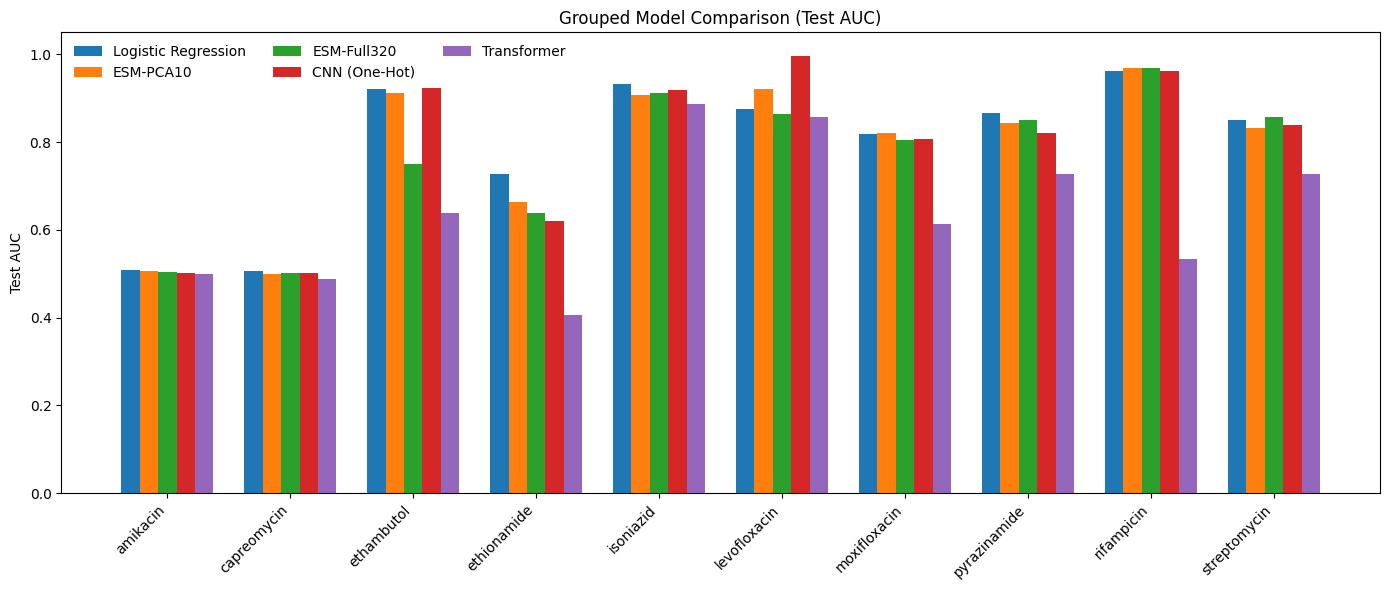

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

# Load combined table (with train/test columns)
df = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# -----------------------------------------
# Step 1: Aggregate groups (use test AUC only)
# -----------------------------------------
df_grouped = pd.DataFrame({
    "drug": df["drug"],
    # Regression group: mean of lasso/ridge/logreg test AUC
    # "regression": df[["lasso_test_auc", "ridge_test_auc", "logreg_test_auc"]].mean(axis=1),
    "regression": df["logreg_test_auc"],
    # ESM group: two variants
    "esm_pca10": df["esm_pca10_test_auc"],
    "esm_full320": df["esm_full320_test_auc"],
    # CNN + Transformer
    "cnn": df["cnn_test_auc"],
    "transformer": df["transformer_test_auc"]
})

# Drop drugs with missing values (if any)
plot_df = df_grouped.dropna()

# -----------------------------------------
# Step 2: Plot
# -----------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_df['drug']))
width = 0.15

# ax.bar(x - 2*width, plot_df['regression'], width=width, label='Regression (avg)')
ax.bar(x - 2*width, plot_df['regression'], width=width, label='Logistic Regression')
ax.bar(x - 1*width, plot_df['esm_pca10'], width=width, label='ESM-PCA10')
ax.bar(x + 0*width, plot_df['esm_full320'], width=width, label='ESM-Full320')
ax.bar(x + 1*width, plot_df['cnn'], width=width, label='CNN (One-Hot)')
ax.bar(x + 2*width, plot_df['transformer'], width=width, label='Transformer')

# -----------------------------------------
# Step 3: Aesthetics
# -----------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(plot_df['drug'], rotation=45, ha='right')
ax.set_ylabel('Test AUC')
ax.set_ylim(0, 1.05)
ax.set_title('Grouped Model Comparison (Test AUC)')
ax.legend(frameon=False, ncol=3)

plt.tight_lat()
# plt.savefig("data/latest/results/prediction/combined/auc_grouped_models.png", dpi=300)
plt.show()


/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

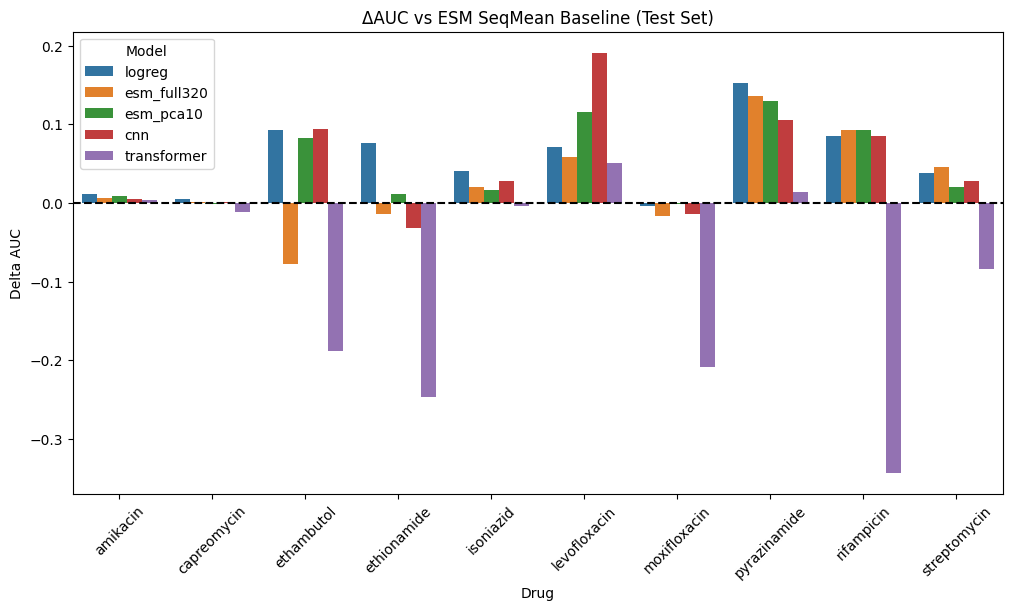

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
# ΔAUC vs ESM SeqMean Baseline (Test Set)")


models = ["logreg", "esm_full320", "esm_pca10", "cnn", "transformer"]

records = []
for _, row in df.iterrows():
    drug = row["drug"]
    baseline = row["esm_seqmean_test_auc"]
    for m in models:
        delta = row[f"{m}_test_auc"] - baseline
        records.append({"Drug": drug, "Model": m, "Delta AUC": delta})

plot_df = pd.DataFrame(records)

plt.figure(figsize=(12,6))
import seaborn as sns
sns.barplot(data=plot_df, x="Drug", y="Delta AUC", hue="Model")
plt.axhline(0, color="black", linestyle="--")
plt.title("ΔAUC vs ESM SeqMean Baseline (Test Set)")
plt.xticks(rotation=45)
plt.show()


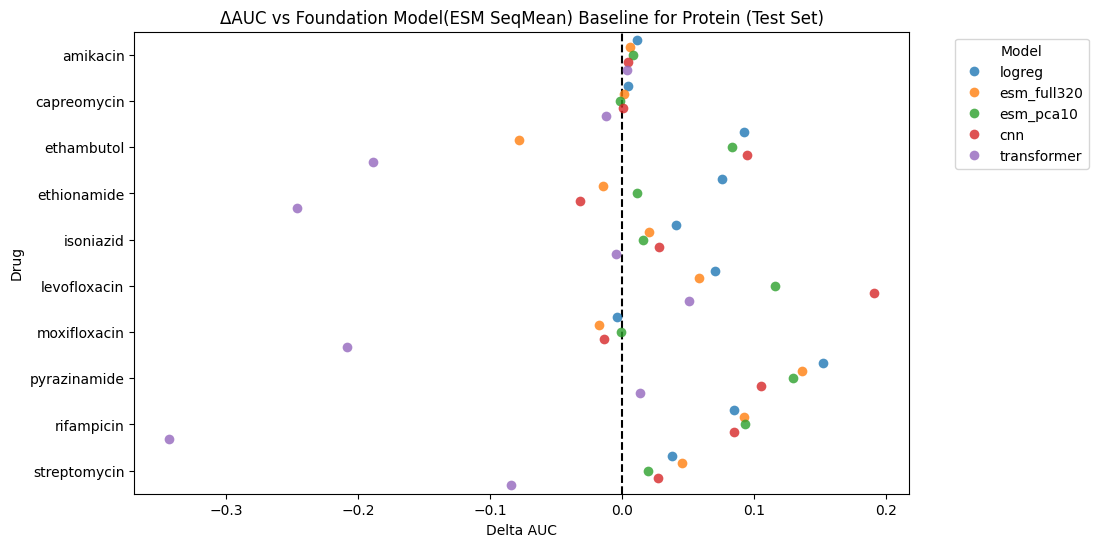

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = ["logreg", "esm_full320", "esm_pca10", "cnn", "transformer"]

records = []
for _, row in df.iterrows():
    drug = row["drug"]
    baseline = row["esm_seqmean_test_auc"]
    for m in models:
        delta = row[f"{m}_test_auc"] - baseline
        records.append({"Drug": drug, "Model": m, "Delta AUC": delta})

plot_df = pd.DataFrame(records)

plt.figure(figsize=(10,6))
sns.stripplot(
    data=plot_df, 
    x="Delta AUC", 
    y="Drug", 
    hue="Model", 
    dodge=True,     # separates the dots by model within each drug
    jitter=True,    # spreads them slightly so they don’t overlap
    alpha=0.8, 
    size=7
)
plt.axvline(0, color="black", linestyle="--")
plt.title("ΔAUC vs Foundation Model(ESM SeqMean) Baseline for Protein (Test Set)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


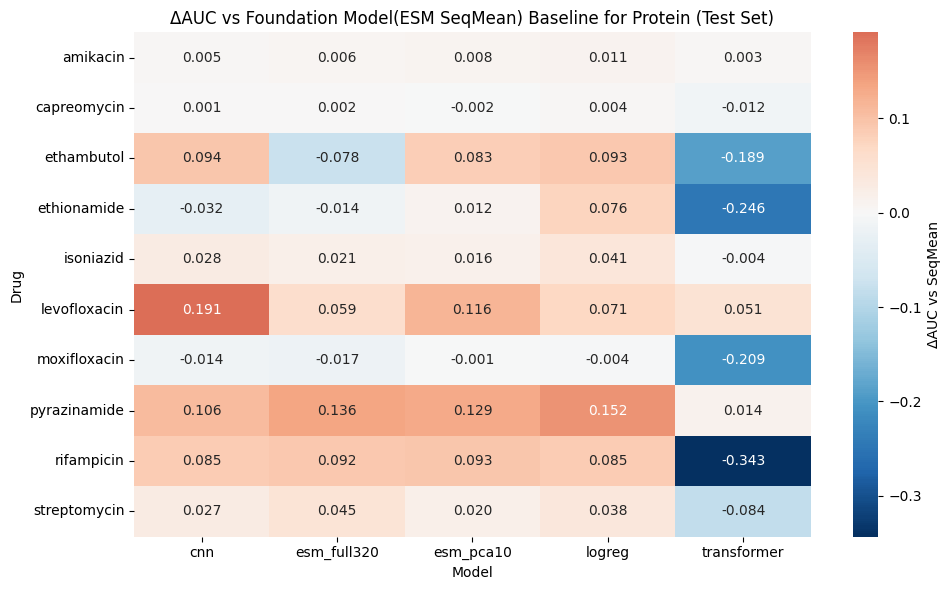

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = ["logreg", "esm_full320", "esm_pca10", "cnn", "transformer"]

records = []
for _, row in df.iterrows():
    drug = row["drug"]
    baseline = row["esm_seqmean_test_auc"]
    for m in models:
        delta = row[f"{m}_test_auc"] - baseline
        records.append({"Drug": drug, "Model": m, "Delta AUC": delta})

plot_df = pd.DataFrame(records)

# Pivot into drug × model matrix
heatmap_df = plot_df.pivot(index="Drug", columns="Model", values="Delta AUC")

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_df, 
    annot=True,       # write values in cells
    fmt=".3f",        # 3 decimal places
    cmap="RdBu_r",    # red=improvement, blue=drop
    center=0,         # white = no change vs baseline
    cbar_kws={"label": "ΔAUC vs SeqMean"}
)
plt.title("ΔAUC vs Foundation Model(ESM SeqMean) Baseline for Protein (Test Set)")
plt.ylabel("Drug")
plt.xlabel("Model")
plt.tight_lat()
plt.show()


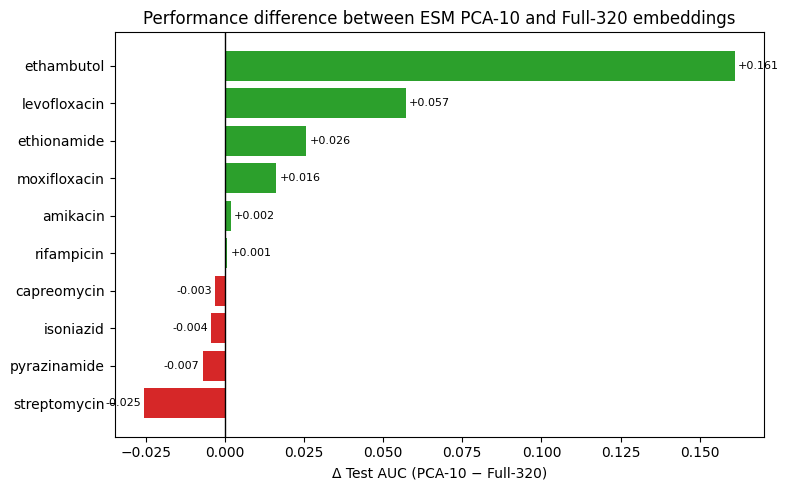

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load new combined table
df_full = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# Select test AUC columns for ESM PCA-10 and Full-320
selected_cols = ["drug", "esm_pca10_test_auc", "esm_full320_test_auc"]
df = df_full[selected_cols].dropna()

# Compute difference PCA-10 minus Full-320
df["delta_auc"] = df["esm_pca10_test_auc"] - df["esm_full320_test_auc"]

# Sort for plotting
df = df.sort_values("delta_auc")

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(
    df["drug"], 
    df["delta_auc"], 
    color=["#2ca02c" if d > 0 else "#d62728" for d in df["delta_auc"]]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Δ Test AUC (PCA-10 − Full-320)")
plt.title("Performance difference between ESM PCA-10 and Full-320 embeddings")

# Annotate values
for bar, val in zip(bars, df["delta_auc"]):
    plt.text(
        val + (0.001 if val >= 0 else -0.001), 
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=8
    )

plt.tight_lat()
plt.savefig("data/latest/results/prediction/combined/delta_pca10_full320_auc.png", dpi=300)
plt.show()

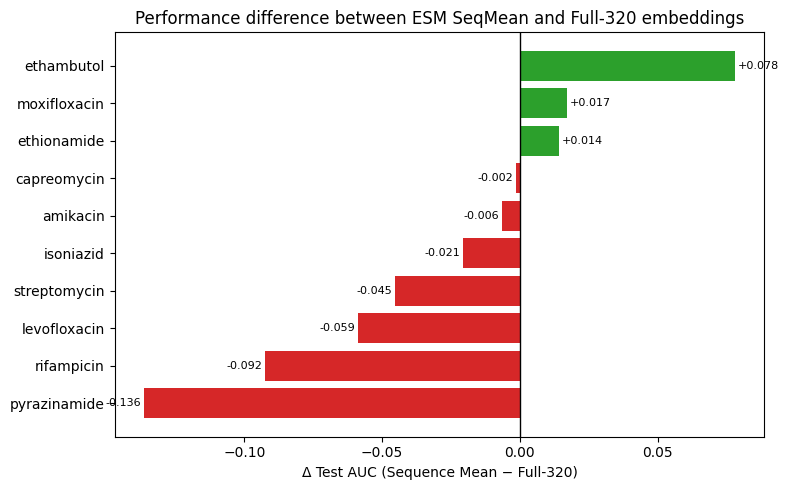

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load new combined table
df_full = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# Select test AUC columns for ESM PCA-10 and Full-320
selected_cols = ["drug", "esm_seqmean_test_auc", "esm_full320_test_auc"]
df = df_full[selected_cols].dropna()

# Compute difference PCA-10 minus Full-320
df["delta_auc"] = df["esm_seqmean_test_auc"] - df["esm_full320_test_auc"]

# Sort for plotting
df = df.sort_values("delta_auc")

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(
    df["drug"], 
    df["delta_auc"], 
    color=["#2ca02c" if d > 0 else "#d62728" for d in df["delta_auc"]]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Δ Test AUC (Sequence Mean − Full-320)")
plt.title("Performance difference between ESM SeqMean and Full-320 embeddings")

# Annotate values
for bar, val in zip(bars, df["delta_auc"]):
    plt.text(
        val + (0.001 if val >= 0 else -0.001), 
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=8
    )

plt.tight_lat()
plt.savefig("data/latest/results/prediction/combined/delta_seqmean_full320_auc.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# Config
# -----------------------------
INPUT_CSV = "data/latest/results/prediction/ESM_train_test_auc.csv"
OUT_DIR   = Path("data/latest/results/prediction/combined")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load esm results
# -----------------------------
df = pd.read_csv(INPUT_CSV)

# -----------------------------
# Helper: pick AUC by variant
# -----------------------------
def pick_variant(drug, kind, metric="test_auc"):
    if kind == "full320":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 320)
    elif kind == "pca10":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 10)
    elif kind == "pca1":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 1)
    elif kind == "mean1":
        sel = (df.drug == drug) & (df.dim_type == "mean")
    elif kind == "seqmean1":
        sel = (df.drug == drug) & (df.dim_type == "seqmean")
    else:
        raise ValueError(kind)
    sub = df.loc[sel, metric]
    return float(sub.iloc[0]) if len(sub) else float("nan")

# -----------------------------
# Collect wide table
# -----------------------------
drugs = sorted(df["drug"].unique())
variants = ["full320", "pca10", "pca1", "mean1", "seqmean1"]

wide = pd.DataFrame({"drug": drugs})
for v in variants:
    wide[v] = [pick_variant(d, v, metric="test_auc") for d in drugs]

# Drop drugs missing baseline (seqmean1)
wide = wide.dropna(subset=["seqmean1"]).reset_index(drop=True)

# -----------------------------
# Compute deltas vs seqmean1
# -----------------------------
baseline = "seqmean1"
for v in ["pca10", "pca1", "mean1", "full320"]:
    wide[f"delta_{v}"]  = wide[v] - wide[baseline]
    wide[f"ndelta_{v}"] = (wide[v] - wide[baseline]) / wide[baseline]

# Save tidy summary
summary_cols = ["drug", baseline, "full320","pca10","pca1","mean1"] + \
               [f"delta_{v}" for v in ["pca10","pca1","mean1","full320"]] + \
               [f"ndelta_{v}" for v in ["pca10","pca1","mean1","full320"]]
wide.to_csv(OUT_DIR / "esm_variant_deltas_seqmean_baseline.csv", 
            index=False, columns=summary_cols)

# -----------------------------
# Plot 1: Multi-panel barplots
# -----------------------------
variants_plot = ["pca10","pca1","mean1","full320"]
pretty_names = {"pca10":"PCA-10", "pca1":"PCA-1",
                "mean1":"Channel-mean", "full320":"Full-320"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for ax, v in zip(axes.flatten(), variants_plot):
    col = f"ndelta_{v}"
    sub = wide[["drug", col]].dropna().sort_values(col)

    colors = ["#2ca02c" if val > 0 else "#d62728" for val in sub[col].values]
    bars = ax.barh(sub["drug"], sub[col], color=colors)
    ax.axvline(0, linewidth=1, color="black")

    # Annotate
    for b, val in zip(bars, sub[col].values):
        ax.text(
            val + (0.002 if val >= 0 else -0.002),
            b.get_y() + b.get_height()/2,
            f"{val*100:+.1f}%",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=7
        )

    ax.set_title(f"{pretty_names[v]} vs Seq-mean")
    ax.set_xlabel("Normalized ΔAUC")
    ax.set_ylabel("Drug")

plt.tight_lat()
# plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_compact_subplots.pdf")
plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_compact_subplots.png", dpi=300)
plt.close()

# -----------------------------
# Plot 2: Heatmap
# -----------------------------
heatmap_df = wide[["drug"] + [f"ndelta_{v}" for v in variants_plot]]
heatmap_df = heatmap_df.set_index("drug")
heatmap_df = heatmap_df.rename(columns={f"ndelta_{v}": pretty_names[v] for v in variants_plot})

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt=".1%", cmap="RdBu_r", center=0,
    cbar_kws={"label": "Normalized ΔAUC"}
)
plt.title("ΔAUC vs Seq-mean baseline")
plt.ylabel("Drug")
plt.xlabel("Variant")
plt.tight_lat()
# plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_heatmap.pdf")
plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_heatmap.png", dpi=300)
plt.close()

print(f"Saved summary + figures to: {OUT_DIR.resolve()}")



Saved summary + figures to: /work/pi_annagreen_umass_edu/mahbuba/protein-tasks/data/latest/results/prediction/combined


/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

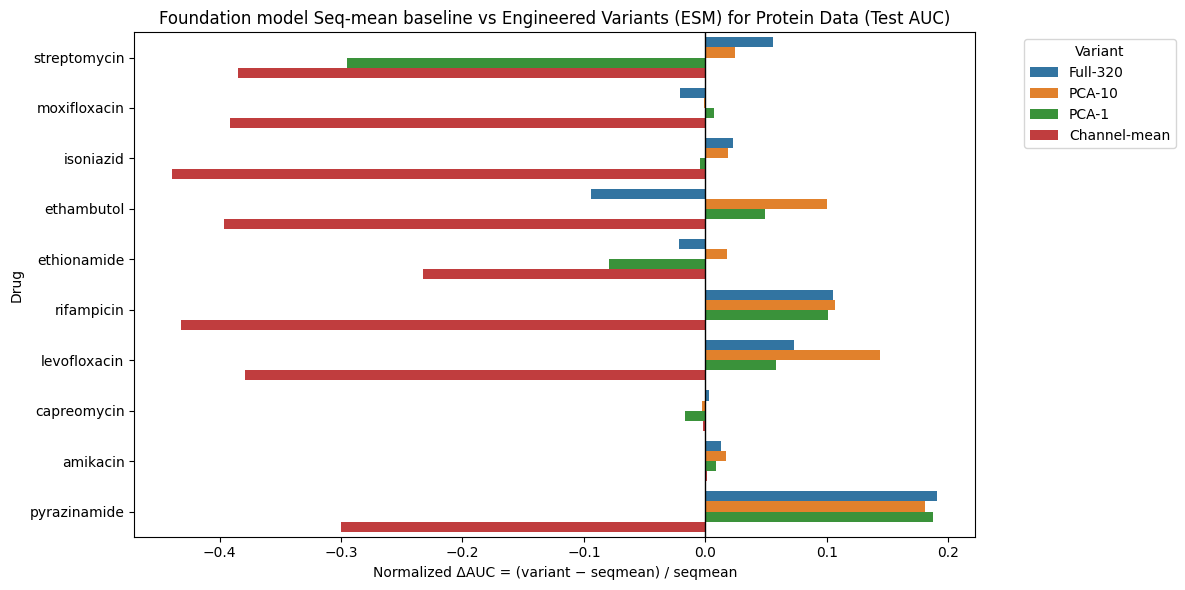

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variants to plot
variants_plot = ["full320","pca10","pca1","mean1"]
pretty_names = {"pca10":"PCA-10", "pca1":"PCA-1",
                "mean1":"Channel-mean", "full320":"Full-320"}

# Collect tidy records
records = []
for _, row in wide.iterrows():
    drug = row["drug"]
    for v in variants_plot:
        records.append({
            "Drug": drug,
            "Variant": pretty_names[v],
            "ΔAUC": row[f"ndelta_{v}"]
        })

plot_df = pd.DataFrame(records)

# Sort drugs for readability (optional: by overall improvement)
drug_order = plot_df.groupby("Drug")["ΔAUC"].mean().sort_values().index

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df, 
    x="ΔAUC", 
    y="Drug", 
    hue="Variant",
    order=drug_order,
    orient="h"
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Normalized ΔAUC = (variant − seqmean) / seqmean")
plt.ylabel("Drug")
plt.title("Foundation model Seq-mean baseline vs Engineered Variants (ESM) for Protein Data (Test AUC)")
plt.legend(title="Variant", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_lat()

# plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_grouped.pdf")
# plt.savefig(OUT_DIR / "esm_variants_vs_seqmean_grouped.png", dpi=300)
plt.show()
plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Config
# -----------------------------
INPUT_CSV = "data/latest/results/prediction/ESM_train_test_auc.csv"
OUT_DIR   = Path("data/latest/results/prediction/combined")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load esm results
# -----------------------------
df = pd.read_csv(INPUT_CSV)

# -----------------------------
# Helper: pick AUC by variant
# -----------------------------
def pick_variant(drug, kind, metric="test_auc"):
    if kind == "full320":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 320)
    elif kind == "pca10":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 10)
    elif kind == "pca1":
        sel = (df.drug == drug) & (df.dim_type == "dim") & (df.dim == 1)
    elif kind == "mean1":
        sel = (df.drug == drug) & (df.dim_type == "mean")
    elif kind == "seqmean1":
        sel = (df.drug == drug) & (df.dim_type == "seqmean")
    else:
        raise ValueError(kind)
    sub = df.loc[sel, metric]
    return float(sub.iloc[0]) if len(sub) else float("nan")

# -----------------------------
# Collect wide table
# -----------------------------
drugs = sorted(df["drug"].unique())
variants = ["full320", "pca10", "pca1", "mean1", "seqmean1"]

wide = pd.DataFrame({"drug": drugs})
for v in variants:
    wide[v] = [pick_variant(d, v, metric="test_auc") for d in drugs]

# Drop drugs missing baseline (seqmean1)
wide = wide.dropna(subset=["seqmean1"]).reset_index(drop=True)

# -----------------------------
# Compute deltas vs seqmean1
# -----------------------------
baseline = "seqmean1"
for v in ["pca10", "pca1", "mean1", "full320"]:
    wide[f"delta_{v}"]  = wide[v] - wide[baseline]
    wide[f"ndelta_{v}"] = (wide[v] - wide[baseline]) / wide[baseline]

# Save tidy summary
summary_cols = ["drug", baseline, "full320","pca10","pca1","mean1"] + \
               [f"delta_{v}" for v in ["pca10","pca1","mean1","full320"]] + \
               [f"ndelta_{v}" for v in ["pca10","pca1","mean1","full320"]]
wide.to_csv(OUT_DIR / "esm_variant_deltas_seqmean_baseline.csv", index=False, columns=summary_cols)

# -----------------------------
# Plot function
# -----------------------------
def plot_ndelta(wdf, variant, fname_prefix):
    col = f"ndelta_{variant}"
    sub = wdf[["drug", col]].dropna().sort_values(col)

    plt.figure(figsize=(7, 4.5))
    colors = ["#2ca02c" if val > 0 else "#d62728" for val in sub[col].values]
    bars = plt.barh(sub["drug"], sub[col], color=colors)
    plt.axvline(0, linewidth=1, color="black")

    ylab = "Normalized ΔAUC = (variant − seqmean) / seqmean"
    pretty = {"pca10":"PCA-10", "pca1":"PCA-1",
              "mean1":"Channel-mean", "full320":"Full-320"}[variant]
    plt.xlabel(ylab)
    plt.title(f"{pretty} vs. Seq-mean (per drug)")

    # annotate (%)
    for b, val in zip(bars, sub[col].values):
        plt.text(
            val + (0.002 if val >= 0 else -0.002),
            b.get_y() + b.get_height()/2,
            f"{val*100:+.1f}%",
            va="center",
            ha="left" if val >= 0 else "right", fontsize=8
        )

    plt.tight_lat()
    plt.savefig(OUT_DIR / f"{fname_prefix}.pdf")
    plt.savefig(OUT_DIR / f"{fname_prefix}.png", dpi=300)
    plt.close()

# -----------------------------
# Generate per-variant figures
# -----------------------------
for v in ["pca10","pca1","mean1","full320"]:
    plot_ndelta(wide, v, f"ndelta_{v}_vs_seqmean")

print(f"Saved figures and summary CSV to: {OUT_DIR.resolve()}")


In [32]:
import pandas as pd

# -----------------------------
# Load esm results
# -----------------------------
df = pd.read_csv("data/latest/results/prediction/ESM_train_test_auc.csv")

# Helper: map rows into variant labels
def esm_variant(row):
    if row["dim_type"] == "dim" and row["dim"] == 1:
        return "pca1"
    elif row["dim_type"] == "dim" and row["dim"] == 10:
        return "pca10"
    elif row["dim_type"] == "dim" and row["dim"] == 320:
        return "full320"
    elif row["dim_type"] == "mean":
        return "mean"
    elif row["dim_type"] == "seqmean":
        return "seqmean"
    else:
        return None

df["variant"] = df.apply(esm_variant, axis=1)

# Pivot: rows=drug, cols=variant, values=test_auc
wide = df.pivot(index="drug", columns="variant", values="test_auc")

# -----------------------------
# 1. Compare seqmean vs others
# -----------------------------
comparison = {}
for drug in wide.index:
    if pd.notna(wide.loc[drug, "seqmean"]):
        seq_val = wide.loc[drug, "seqmean"]
        better_than = {}
        for v in wide.columns:
            if v != "seqmean" and pd.notna(wide.loc[drug, v]):
                diff = seq_val - wide.loc[drug, v]
                if diff > 0:
                    better_than[v] = diff
        comparison[drug] = {
            "seqmean_auc": seq_val,
            "seqmean_better_than": better_than if better_than else None
        }
    else:
        comparison[drug] = {
            "seqmean_auc": None,
            "seqmean_better_than": None
        }

# -----------------------------
# 2. Find the best variant
# -----------------------------
best_variants = wide.idxmax(axis=1)     # which variant is best
best_scores   = wide.max(axis=1)        # best AUC

# -----------------------------
# 3. Combine summary
# -----------------------------
summary = pd.DataFrame.from_dict(comparison, orient="index")
summary["best_variant"] = best_variants
summary["best_auc"] = best_scores
summary = summary.reset_index().rename(columns={"index": "drug"})

# Save summary
summary.to_csv("data/latest/results/prediction/combined/esm_seqmean_vs_others_summary.csv", index=False)

print(summary)

# -----------------------------
# 4. Global tally of best variants
# -----------------------------
tally = best_variants.value_counts()
print("\n=== Count of Best Variants Across Drugs ===")
print(tally)


           drug  seqmean_auc  \
0      amikacin     0.496933   
1   capreomycin     0.500798   
2    ethambutol     0.828147   
3   ethionamide     0.651732   
4     isoniazid     0.891073   
5  levofloxacin     0.805556   
6  moxifloxacin     0.821332   
7  pyrazinamide     0.714435   
8    rifampicin     0.876212   
9  streptomycin     0.812538   

                                 seqmean_better_than best_variant  best_auc  
0                                               None        pca10  0.505266  
1  {'mean': 0.0007978103890053934, 'pca1': 0.0082...      full320  0.502324  
2  {'full320': 0.07797002835907096, 'mean': 0.328...        pca10  0.911204  
3  {'full320': 0.014218422527027874, 'mean': 0.15...        pca10  0.663232  
4  {'mean': 0.3910733500717358, 'pca1': 0.0037186...      full320  0.911733  
5                      {'mean': 0.30555555555555547}        pca10  0.921429  
6  {'full320': 0.017217448777263722, 'mean': 0.32...         pca1  0.827032  
7                      

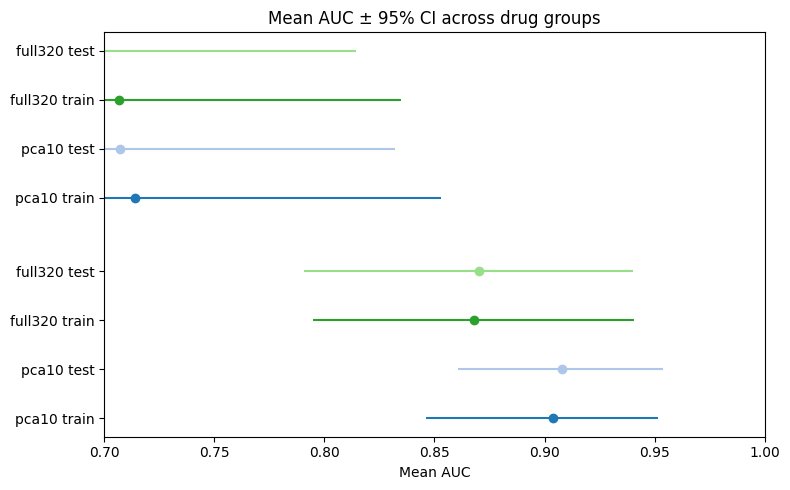

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

# Load  dataframe
df = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# Define drug groups
first_line = ["isoniazid", "rifampicin", "ethambutol", "pyrazinamide"]
second_line = ["streptomycin", "amikacin", "capreomycin", "levofloxacin", "moxifloxacin", "ethionamide"]

def mean_ci(values, n_boot=10000):
    values = np.array(values)
    res = bootstrap([values], np.mean, confidence_level=0.95, n_resamples=n_boot, method="percentile")
    return values.mean(), res.confidence_interval.low, res.confidence_interval.high

# Collect summary stats
rows = []
for group_name, drugs in [("First line drugs", first_line), ("Second line drugs", second_line)]:
    subset = df[df["drug"].isin(drugs)]
    for model in ["esm_pca10", "esm_full320"]:
        for split in ["train", "test"]:
            aucs = subset[f"{model}_{split}_auc"]
            mean, lo, hi = mean_ci(aucs)
            rows.append({"group": group_name, "label": f"{model}_{split}", 
                         "mean": mean, "lo": lo, "hi": hi})
panel_a = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(8,5))
colors = {
    "esm_pca10_train":"#1f77b4", 
    "esm_pca10_test":"#aec7e8",
    "esm_full320_train":"#2ca02c", 
    "esm_full320_test":"#98df8a"
}

# Order like paper: PCA-10 train/test, Full-320 train/test
order = ["esm_pca10_train", "esm_pca10_test", "esm_full320_train", "esm_full320_test"]

yticks, ylabels = [], []
ypos = 0
for grp in panel_a["group"].unique():
    grp_df = panel_a[panel_a["group"]==grp].set_index("label").loc[order]
    for lbl, row in grp_df.iterrows():
        plt.errorbar(row["mean"], ypos, 
                     xerr=[[row["mean"]-row["lo"]],[row["hi"]-row["mean"]]],
                     fmt="o", color=colors[lbl])
        ylabels.append(lbl.replace("esm_","").replace("_"," "))
        yticks.append(ypos)
        ypos += 1
    ypos += 0.5  # gap between groups

plt.yticks(yticks, ylabels)
plt.xlabel("Mean AUC")
plt.xlim(0.7, 1.0)
plt.title("Mean AUC ± 95% CI across drug groups")
plt.axvline(0.5, color="grey", linestyle="--", alpha=0.5)
plt.tight_lat()
plt.show()


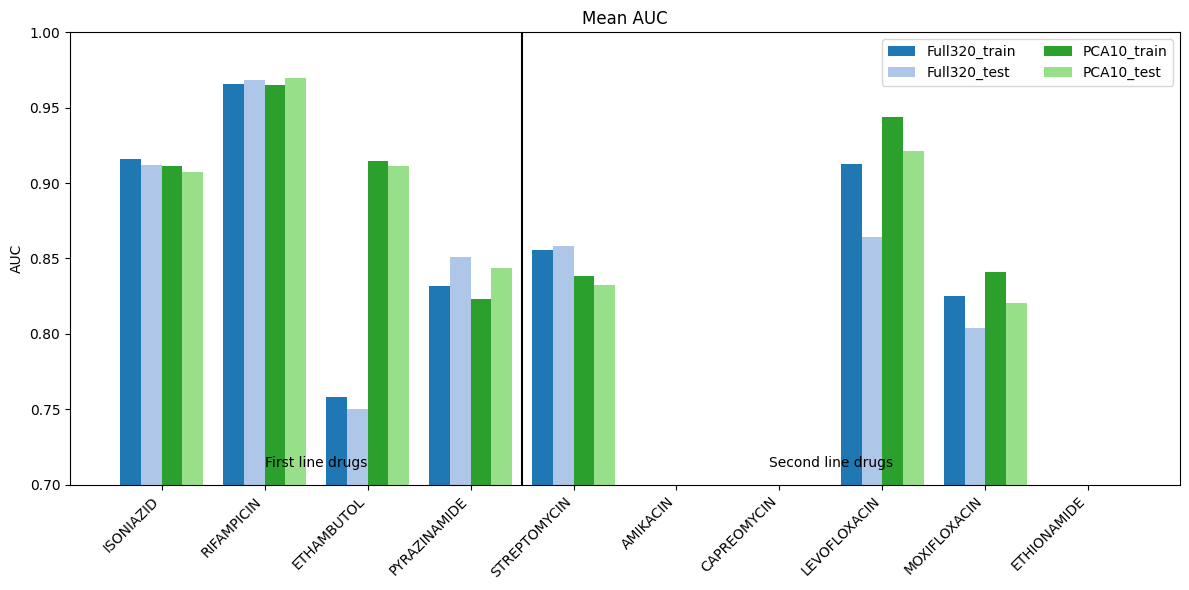

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load  data
df = pd.read_csv("data/latest/results/prediction/combined/Combined_train_test_aucs_Table.csv")

# Drugs in desired order (first-line then second-line, like their figure)
first_line = ["isoniazid", "rifampicin", "ethambutol", "pyrazinamide"]
second_line = ["streptomycin", "amikacin", "capreomycin", "levofloxacin", "moxifloxacin", "ethionamide"]
drug_order = first_line + second_line

df = df.set_index("drug").loc[drug_order].reset_index()

# Plot setup
x = np.arange(len(drug_order))  # drug positions
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Full-320 train/test
ax.bar(x - 1.5*width, df["esm_full320_train_auc"], width, label="Full320_train", color="#1f77b4")
ax.bar(x - 0.5*width, df["esm_full320_test_auc"],  width, label="Full320_test",  color="#aec7e8")

# PCA-10 train/test
ax.bar(x + 0.5*width, df["esm_pca10_train_auc"], width, label="PCA10_train", color="#2ca02c")
ax.bar(x + 1.5*width, df["esm_pca10_test_auc"],  width, label="PCA10_test",  color="#98df8a")

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in drug_order], rotation=45, ha="right")
ax.set_ylabel("AUC")
ax.set_ylim(0.70, 1.0)
ax.set_title("Mean AUC")
ax.legend(ncol=2)

# Add separators for first vs second line drugs
ax.axvline(len(first_line) - 0.5, color="black", linestyle="-")
ax.text(len(first_line)/2 - 0.5, 0.71, "First line drugs", ha="center", va="bottom")
ax.text(len(first_line) + len(second_line)/2 - 0.5, 0.71, "Second line drugs", ha="center", va="bottom")

plt.tight_lat()
plt.show()


## precision recall visualizations

In [10]:
from pathlib import Path
import pandas as pd

BASE = Path("data/latest/results/interpretability")

# TARGETS = {
#     "full320":     "full_320",
#     "pca10":       "pca_10",
#     # "channelmean":  "mean",
#     # "pca1":         "pca_1",
#     "cnn":         "cnn",
#     "transformer": "transformer",
#     "regression":  "regression",
# }

# each entry: key → (subfolder, filename)
TARGETS = {
    "full320":     ("full_320",       "precision_recall_all_drugs_shapall.csv"),
    "pca10":       ("pca_10",         "precision_recall_all_drugs_shapall.csv"),
    "cnn":         ("cnn",            "precision_recall_all_drugs_shapall.csv"),
    "transformer": ("transformer",    "precision_recall_all_drugs_shapall.csv"),
    "regression":  ("regression",     "precision_recall_all_drugs.csv"),  # <-- different
}
SUBDIR = "pr_tables"

def load_one_variant(variant_name: str, subfolder: str, fname: str) -> pd.DataFrame:
    """Load and normalize one variant's PR table."""
    csv_path = BASE / subfolder / SUBDIR / fname
    if not csv_path.exists():
        hits = list((BASE / subfolder).rglob(fname))
        if hits:
            csv_path = hits[0]
        else:
            print(f"[WARN] Missing: {variant_name} expected at {csv_path}")
            return pd.DataFrame()

    df = pd.read_csv(csv_path)

    # Case-insensitive name map
    cols = {c.lower(): c for c in df.columns}
    def pick(*names, default=None):
        for n in names:
            if n in cols:
                return df[cols[n]]
        return default

    drug   = pick("drug")
    gene   = pick("gene")
    k_req  = pick("k_req", "k")
    k_eff  = pick("k_eff", default=k_req)
    total  = pick("total_res_pos", "total_resistance_positions")
    tp     = pick("tp")
    prec   = pick("precision")
    rec    = pick("recall")
    f1     = pick("f1")
    hits   = pick("hit_variants", "identified_variants")
    model  = pick("model")  # only in regression

    out = pd.DataFrame({
        "variant":       (model.str.lower() if (variant_name == "regression" and model is not None)
                          else pd.Series([variant_name]*len(df))),
        "drug":          drug,
        "gene":          gene,
        "k_req":         k_req,
        "k_eff":         k_eff if k_eff is not None else k_req,
        "total_res_pos": total,
        "TP":            tp,
        "precision":     prec,
        "recall":        rec,
        "F1":            f1,
        "variants":      hits,
    })

    out["family"] = variant_name

    for c in ["k_req","k_eff","total_res_pos","TP","precision","recall","F1"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    return out.dropna(subset=["drug","gene"]).reset_index(drop=True)


# Load all
frames = [load_one_variant(v, sub, fname) for v,(sub,fname) in TARGETS.items()]
combined = pd.concat([f for f in frames if not f.empty], ignore_index=True)

# Sort & save
sort_cols = [c for c in ["variant","family","drug","gene","k_req"] if c in combined.columns]
combined = combined.sort_values(sort_cols).reset_index(drop=True)

out_dir = BASE / "combined"
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "combined_precision_recall_all_models_shapall.csv"
combined.to_csv(out_csv, index=False)
print(f"Combined table written to: {out_csv}")


Combined table written to: data/latest/results/interpretability/combined/combined_precision_recall_all_models_shapall.csv


In [ ]:
"""
SHAP causal-variant summaries and plots
---------------------------------------
Input:  combined PR CSV produced earlier (one row per variant/drug/gene/k)
Output:
  - tables/
      shap_model_summary_k10.csv
      shap_model_summary_k10.tex
      shap_pca10_detailed_k10.csv
      shap_pca10_detailed_k10.tex
      shap_delta_pca10_vs_full320.txt
  - figs/
      macro_recall_k_esm.pdf
      macro_f1_k_esm.pdf
      macro_recall_k_ohe.pdf
      macro_f1_k_reg.pdf

How macro/micro are computed:
  * Macro: average per-(drug,gene) metric (ignore NaNs).
  * Micro: aggregate counts across (drug,gene), then P,R,F1 from totals.
"""

from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
IN_CSV  = Path("data/latest/results/interpretability/combined/combined_precision_recall_all_models_shapall.csv")
OUT_DIR = Path("data/latest/results/interpretability/combined")
TAB_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figs"
TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_K = 10
# Variants to show in the main summary (others, if present, go to supplement)
# MAIN_VARIANTS = ["lasso","ridge","logreg","pca10","full320","cnn","transformer"]  # add "mean","pca1" later if desired
MAIN_VARIANTS = ["logreg","pca10","full320","cnn","transformer"]  # add "mean","pca1" later if desired

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv(IN_CSV)

# Basic sanity: normalize variant strings to lower
df["variant"] = df["variant"].astype(str).str.lower()
if "family" not in df.columns:
    df["family"] = np.where(df["variant"].isin(["lasso","ridge","logreg"]), "regression", df["variant"])

# Coerce numerics
for c in ["k_req","k_eff","total_res_pos","TP","precision","recall","F1"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Helper: compute per-row metrics from counts (robust to any numeric drift)
def recompute_metrics(sub: pd.DataFrame) -> pd.DataFrame:
    sub = sub.copy()
    # predicted positives at top-k = k_eff
    pred = sub["k_eff"].fillna(0)
    tp   = sub["TP"].fillna(0)
    pos  = sub["total_res_pos"].fillna(0)

    with np.errstate(divide="ignore", invalid="ignore"):
        P = np.where(pred>0, tp / pred, np.nan)
        R = np.where(pos>0,  tp / pos,  np.nan)
        F = np.where((P+R)>0, 2*P*R/(P+R), np.nan)

    sub["P_row"] = P
    sub["R_row"] = R
    sub["F_row"] = F
    return sub

df = recompute_metrics(df)

# -----------------------------
# Macro / Micro helper
# -----------------------------
def macro_micro_by_variant(dfin: pd.DataFrame, ks=(1,5,10)) -> pd.DataFrame:
    rows = []
    for k in ks:
        dd = dfin[dfin["k_req"]==k].copy()
        if dd.empty:
            continue

        # Macro: average per (variant, drug, gene)
        g = dd.groupby(["variant","drug","gene"], as_index=False)[["P_row","R_row","F_row"]].mean(numeric_only=True)
        macro = g.groupby("variant", as_index=False)[["P_row","R_row","F_row"]].mean(numeric_only=True)
        macro.rename(columns={"P_row":"macro_prec","R_row":"macro_recall","F_row":"macro_f1"}, inplace=True)

        # Micro: sum counts then compute
        agg = dd.groupby("variant", as_index=False)[["TP","k_eff","total_res_pos"]].sum(numeric_only=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            micro_prec   = np.where(agg["k_eff"]>0, agg["TP"]/agg["k_eff"], np.nan)
            micro_recall = np.where(agg["total_res_pos"]>0, agg["TP"]/agg["total_res_pos"], np.nan)
            micro_f1     = np.where((micro_prec+micro_recall)>0, 2*micro_prec*micro_recall/(micro_prec+micro_recall), np.nan)

        res = macro.merge(agg[["variant","TP"]], on="variant", how="left")
        res["micro_prec"]   = micro_prec
        res["micro_recall"] = micro_recall
        res["micro_f1"]     = micro_f1
        res["k"]            = k
        rows.append(res)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    return out

summary_allk = macro_micro_by_variant(df, ks=[1,5,10])

# -----------------------------
# Summary @ k=10 (main table)
# -----------------------------
summary_k10 = summary_allk[summary_allk["k"]==PRIMARY_K].copy()

# Ensure we include MAIN_VARIANTS if present; also add "mean","pca1" if they exist
extras = [v for v in ["mean","pca1"] if v in summary_k10["variant"].unique()]
order  = [v for v in MAIN_VARIANTS if v in summary_k10["variant"].unique()] + extras
summary_k10 = summary_k10.set_index("variant").loc[order].reset_index()

# Save CSV
summary_k10.to_csv(TAB_DIR / "shap_model_summary_k10.csv", index=False)

# Save LaTeX tabular
def fmt(x, nd=3):
    if pd.isna(x): return "--"
    return f"{x:.{nd}f}"

lines = []
lines.append("\\begin{table}[ht]")
lines.append("\\centering")
lines.append("\\caption{\\small SHAP-based causal variant recovery at top-$k{=}10$ across models. Macro scores average per gene; micro scores pool counts across genes.}")
lines.append("\\label{tab:shap_model_summary}")
lines.append("\\resizebox{\\linewidth}{!}{%")
lines.append("\\begin{tabular}{l|ccc|ccc|c}")
lines.append("\\toprule")
lines.append("\\multirow{2}{*}{\\textbf{Model (variant)}} & \\multicolumn{3}{c|}{\\textbf{Macro} (@$k{=}10$)} & \\multicolumn{3}{c|}{\\textbf{Micro} (@$k{=}10$)} & \\textbf{TP@10}\\\\")
lines.append("& Prec & Rec & F1 & Prec & Rec & F1 & (total) \\\\")
lines.append("\\midrule")
for _, r in summary_k10.iterrows():
    nm = r["variant"]
    row = f"{nm} & {fmt(r['macro_prec'])} & {fmt(r['macro_recall'])} & {fmt(r['macro_f1'])} & {fmt(r['micro_prec'])} & {fmt(r['micro_recall'])} & {fmt(r['micro_f1'])} & {int(r['TP'])}"
    lines.append(row + " \\\\")
lines.append("\\bottomrule")
lines.append("\\end{tabular}%")
lines.append("}")
lines.append("\\end{table}")
(Path(TAB_DIR) / "shap_model_summary_k10.tex").write_text("\n".join(lines))

# -----------------------------
# PCA-10 detailed table @ k=10
# -----------------------------
pca10_k10 = df[(df["variant"]=="pca10") & (df["k_req"]==PRIMARY_K)].copy()
# Keep useful columns; escape underscores for LaTeX in variants column
def escape_tex(s: str) -> str:
    if pd.isna(s): return ""
    return str(s).replace("_", "\\_")

pca10_k10["variants_tex"] = pca10_k10.get("variants", "").apply(escape_tex)

cols = ["drug","gene","total_res_pos","TP","precision","recall","F1","variants"]
pca10_k10[cols].to_csv(TAB_DIR / "shap_pca10_detailed_k10.csv", index=False)

# LaTeX (tabular; adjust to longtable if many rows)
lines2 = []
lines2.append("\\begin{table}[ht]")
lines2.append("\\centering")
lines2.append("\\small")
lines2.append("\\caption{\\small SHAP recovery for ESM CNN (PCA-10) at top-$k{=}10$ by drug/gene. Total resistance positions from the WHO set.}")
lines2.append("\\label{tab:shap_pca10_detailed}")
lines2.append("\\resizebox{\\linewidth}{!}{%")
lines2.append("\\begin{tabular}{l l r r c c c l}")
lines2.append("\\toprule")
lines2.append("\\textbf{Drug} & \\textbf{Gene} & \\textbf{\\#Res.~Pos.} & \\textbf{TP@10} & \\textbf{Prec@10} & \\textbf{Rec@10} & \\textbf{F1@10} & \\textbf{Identified Variants} \\\\")
lines2.append("\\midrule")
for _, r in pca10_k10.sort_values(["drug","gene"]).iterrows():
    row = f"{r['drug']} & \\textit{{{r['gene']}}} & {int(r['total_res_pos'])} & {int(r['TP'])} & {fmt(r['precision'])} & {fmt(r['recall'])} & {fmt(r['F1'])} & {escape_tex(str(r.get('variants','')))}"
    lines2.append(row + " \\\\")
lines2.append("\\bottomrule")
lines2.append("\\end{tabular}%")
lines2.append("}")
lines2.append("\\end{table}")
(Path(TAB_DIR) / "shap_pca10_detailed_k10.tex").write_text("\n".join(lines2))

# -----------------------------
# Delta stats: PCA-10 vs Full-320 @ k=10 (macro F1)
# -----------------------------
def get_metric(summary, variant, metric):
    sub = summary[(summary["k"]==PRIMARY_K) & (summary["variant"]==variant)]
    return float(sub[metric].iloc[0]) if len(sub) else np.nan

pca10_f1  = get_metric(summary_allk, "pca10", "macro_f1")
full_f1   = get_metric(summary_allk, "full320", "macro_f1")
delta_f1  = pca10_f1 - full_f1
rel_delta = delta_f1 / full_f1 if (full_f1 and not pd.isna(full_f1)) else np.nan

with open(TAB_DIR / "shap_delta_pca10_vs_full320.txt","w") as f:
    f.write(f"PCA-10 macro F1@{PRIMARY_K}: {pca10_f1:.3f}\n")
    f.write(f"Full-320 macro F1@{PRIMARY_K}: {full_f1:.3f}\n")
    f.write(f"ΔF1 (PCA-10 − Full-320): {delta_f1:+.3f} ({rel_delta*100:+.1f}%)\n")

# -----------------------------
# Curves vs k (macro)
# -----------------------------
def macro_curve(dfin: pd.DataFrame, variants: list, metric: str, ylabel: str, outpath: Path):
    # Build (k, value) per variant
    ks = sorted(dfin["k"].dropna().unique())
    plt.figure(figsize=(5.2, 4.0))
    for v in variants:
        sub = dfin[(dfin["variant"]==v)]
        vals = [np.nan]
        vals = [float(sub[sub["k"]==k][metric].iloc[0]) if len(sub[sub["k"]==k]) else np.nan for k in ks]
        plt.plot(ks, vals, marker="o", label=v)
    plt.xlabel("k (top-k residues)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs k")
    plt.legend()
    plt.tight_lat()
    plt.savefig(outpath)
    plt.close()

# ESM: PCA-10 vs Full-320
macro_curve(summary_allk, ["pca10","full320"], "macro_recall", "Macro Recall", FIG_DIR / "macro_recall_k_esm.pdf")
macro_curve(summary_allk, ["pca10","full320"], "macro_f1",     "Macro F1",     FIG_DIR / "macro_f1_k_esm.pdf")

# OHE: CNN vs Transformer
macro_curve(summary_allk, ["cnn","transformer"], "macro_recall", "Macro Recall", FIG_DIR / "macro_recall_k_ohe.pdf")

# Regression: Lasso / Ridge / LogReg
macro_curve(summary_allk, ["lasso","ridge","logreg"], "macro_f1", "Macro F1", FIG_DIR / "macro_f1_k_reg.pdf")

print("Done.")
print(f"- Summary CSV: {TAB_DIR / 'shap_model_summary_k10.csv'}")
print(f"- Summary LaTeX: {TAB_DIR / 'shap_model_summary_k10.tex'}")
print(f"- PCA-10 detailed CSV: {TAB_DIR / 'shap_pca10_detailed_k10.csv'}")
print(f"- PCA-10 detailed LaTeX: {TAB_DIR / 'shap_pca10_detailed_k10.tex'}")
print(f"- Figures saved to: {FIG_DIR}")


Done.
- Summary CSV: data/latest/results/interpretability/combined/tables/shap_model_summary_k10.csv
- Summary LaTeX: data/latest/results/interpretability/combined/tables/shap_model_summary_k10.tex
- PCA-10 detailed CSV: data/latest/results/interpretability/combined/tables/shap_pca10_detailed_k10.csv
- PCA-10 detailed LaTeX: data/latest/results/interpretability/combined/tables/shap_pca10_detailed_k10.tex
- Figures saved to: data/latest/results/interpretability/combined/figs


In [12]:
import pandas as pd

# Load file
df = pd.read_csv("data/latest/results/interpretability/combined/combined_precision_recall_all_models_shapall.csv")

# Step 1. Aggregate across genes per (drug, variant, k)
agg = (
    df.groupby(["drug", "variant", "k_req"], as_index=False)
      .agg({"TP": "sum", "total_res_pos": "sum"})
)

# Step 2. Compute percentage
agg["perc_residue_discovered"] = agg.apply(
    lambda row: row["TP"] / row["total_res_pos"] if row["total_res_pos"] > 0 else 0.0,
    axis=1
)

# Step 3. Pivot and save per k
for k in [1, 5, 10]:
    pivot = (
        agg[agg["k_req"] == k]
        .pivot(index="drug", columns="variant", values="perc_residue_discovered")
        .fillna(0)
    )
    
    # optional sort
    pivot = pivot.sort_index().sort_index(axis=1)

    outname = f"data/latest/results/interpretability/combined/perc_discovered_k{k}.csv"
    pivot.to_csv(outname)
    print(f"Saved {outname}")
    print(pivot.head(10))


Saved data/latest/results/interpretability/combined/perc_discovered_k1.csv
variant            cnn   full320     lasso    logreg     pca10     ridge  \
drug                                                                       
amikacin      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
capreomycin   0.500000  0.000000  0.000000  0.000000  0.000000  0.000000   
ethambutol    0.000000  0.000000  0.166667  0.166667  0.166667  0.000000   
ethionamide   0.100000  0.100000  0.100000  0.100000  0.100000  0.100000   
isoniazid     0.666667  0.333333  0.333333  0.333333  0.333333  0.333333   
levofloxacin  0.200000  0.100000  0.100000  0.100000  0.100000  0.100000   
moxifloxacin  0.100000  0.100000  0.200000  0.200000  0.100000  0.200000   
pyrazinamide  0.010526  0.010526  0.010526  0.000000  0.010526  0.010526   
rifampicin    0.038462  0.038462  0.038462  0.038462  0.038462  0.038462   
streptomycin  0.200000  0.200000  0.100000  0.100000  0.200000  0.100000   

variant     

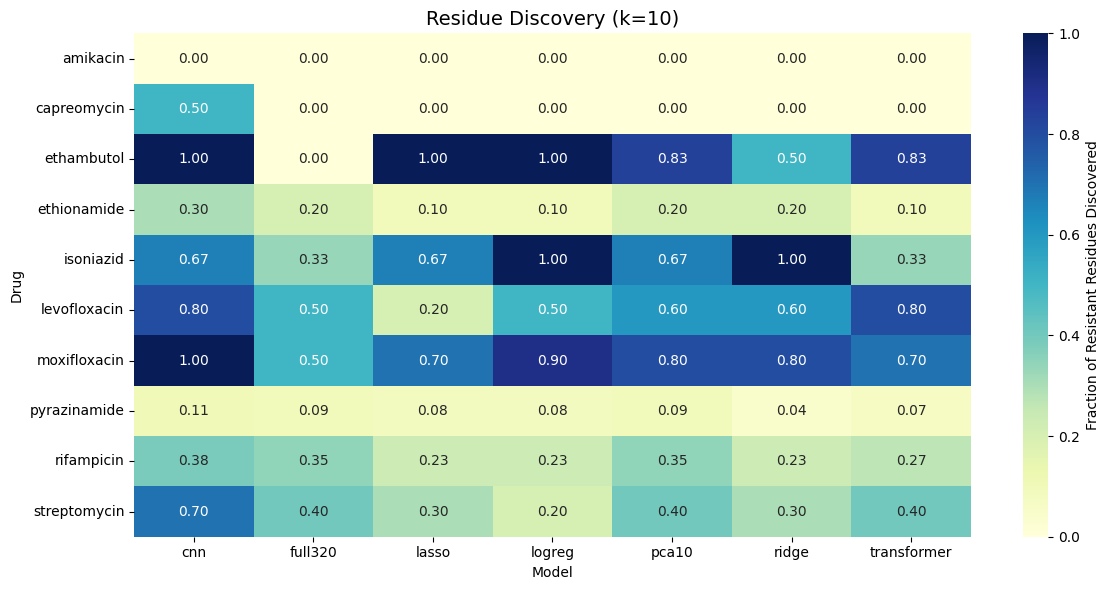

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(pivot_df, k):
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        pivot_df, 
        annot=True, fmt=".2f",  # two decimals
        cmap="YlGnBu", 
        cbar_kws={'label': 'Fraction of Resistant Residues Discovered'}
    )
    plt.title(f"Residue Discovery (k={k})", fontsize=14)
    plt.xlabel("Model")
    plt.ylabel("Drug")
    plt.tight_lat()
    plt.show()

pivot_df_k10 = pd.read_csv("data/latest/results/interpretability/combined/perc_discovered_k10.csv", index_col=0)
# Example usage:
plot_heatmap(pivot_df_k10, k=10)
#Of all resistant residues known for this drug, what fraction did this model recover at top-k?


In [14]:
pivot_df_k10.columns

Index(['cnn', 'full320', 'lasso', 'logreg', 'pca10', 'ridge', 'transformer'], dtype='object')

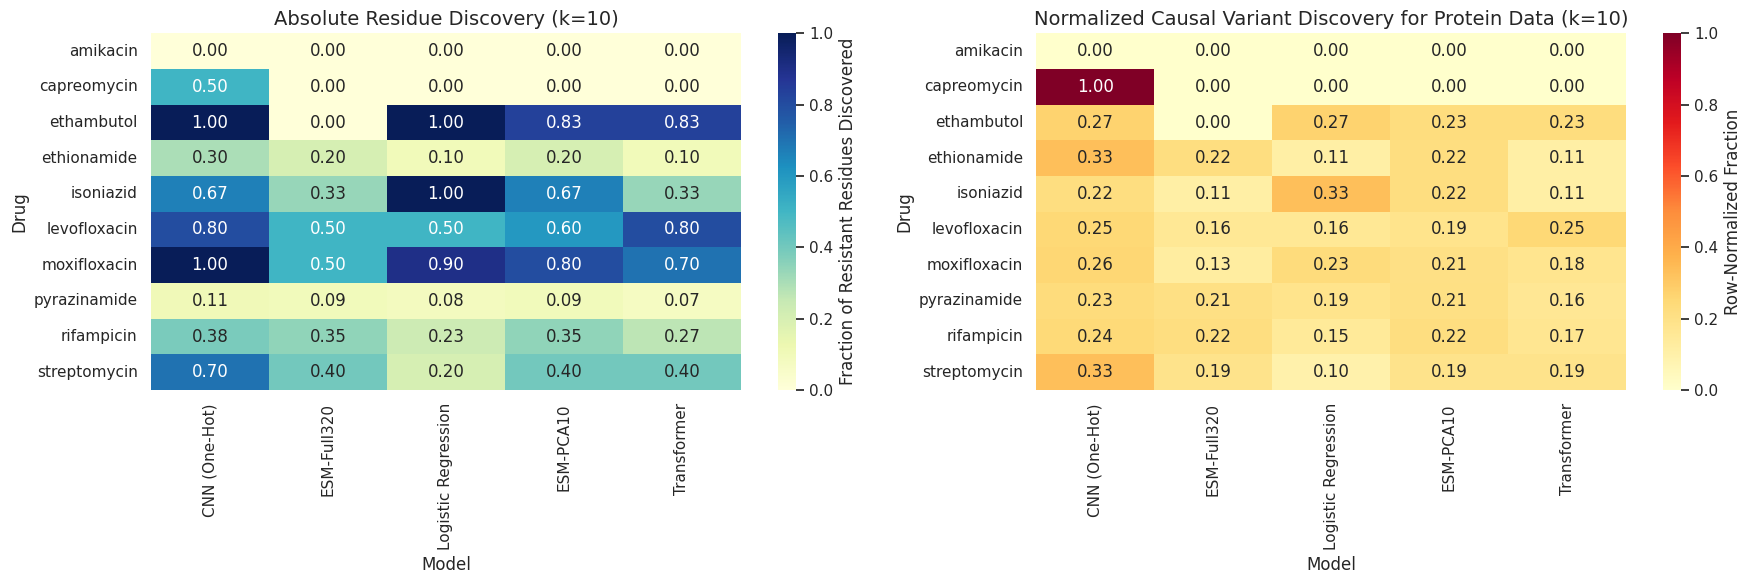

In [ ]:
# Within this drug, what fraction of the models’ total is explained by each model? -row normalization
#highlight relative ranking of models per drug

# Mapping from internal keys to pretty labels
MODEL_NAME_MAP = {
    "logreg":     "Logistic Regression",
    "pca10":      "ESM-PCA10",
    "full320":    "ESM-Full320",
    "cnn":        "CNN (One-Hot)",
    "transformer":"Transformer",
    # optional: "lasso": "Lasso", "ridge": "Ridge"
}

def plot_heatmap_versions(pivot_df, k):
    # drop models  don't want
    pivot_df = pivot_df.drop(columns=["lasso", "ridge"], errors="ignore")

    # rename columns for plotting
    pivot_df = pivot_df.rename(columns=MODEL_NAME_MAP)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # ── 1. Absolute
    sns.heatmap(
        pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0],
        cbar_kws={'label': 'Fraction of Resistant Residues Discovered'}
    )
    axes[0].set_title(f"Absolute Residue Discovery (k={k})", fontsize=14)
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel("Drug")

    # ── 2. Row-normalized
    row_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0).fillna(0)
    sns.heatmap(
        row_norm, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1],
        cbar_kws={'label': 'Row-Normalized Fraction'}
    )
    axes[1].set_title(f"Normalized Causal Variant Discovery for Protein Data (k={k})", fontsize=14)
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Drug")

    plt.tight_lat()
    plt.show()

# Example usage
plot_heatmap_versions(pivot_df_k10, k=10)


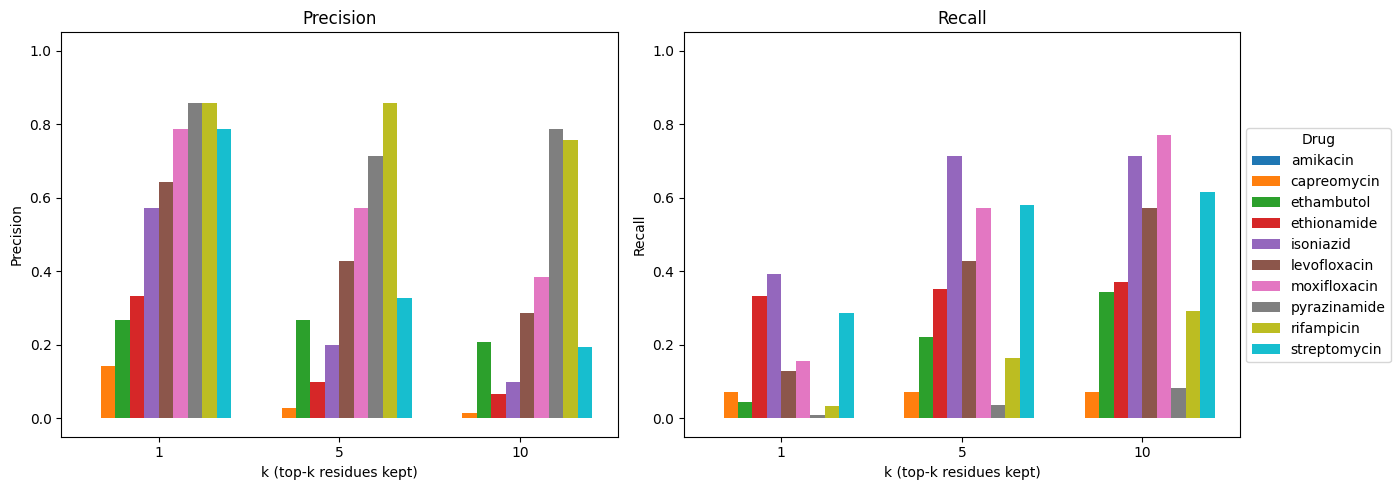

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
import numpy as np

# df = pd.read_csv("data/latest/results/interpretability/combined/combined_precision_recall_all_models.csv")

# ── drug-level aggregation (mean of genes) ────────────────────
agg = (df.groupby(["drug", "k_req"], as_index=False)
         .agg({"precision":"mean", "recall":"mean"}))

drugs   = agg["drug"].unique()
k_vals  = [1,5,10]
colours = plt.cm.tab10(range(len(drugs)))   # distinct colours
x = np.arange(len(k_vals))                  # positions for k’s
bar_width = 0.08                            # adjust for #drugs

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

metrics = ["precision", "recall"]
for ax, metric in zip(axes, metrics):
    for i, (d, c) in enumerate(zip(drugs, colours)):
        sub = (agg[agg["drug"]==d]
                 .set_index("k_req")
                 .reindex(k_vals))  # ensures 1-5-10 order
        ax.bar(x + i*bar_width, sub[metric], 
               width=bar_width, label=d, color=c)
    ax.set_ylim(-0.05,1.05)
    ax.set_title(metric.capitalize())
    ax.set_xticks(x + (len(drugs)-1)*bar_width/2)
    ax.set_xticklabels(k_vals)
    ax.set_xlabel("k (top-k residues kept)")
    ax.set_ylabel(metric.capitalize())

# put ONE legend for the whole figure
fig.legend(drugs, loc="center right", title="Drug")
fig.tight_lat(rect=[0,0,0.90,1])   # leave space on the right
fig.savefig("data/latest/results/interpretability/combined/precision_recall_side_by_side_bars.png", dpi=300)
plt.show()


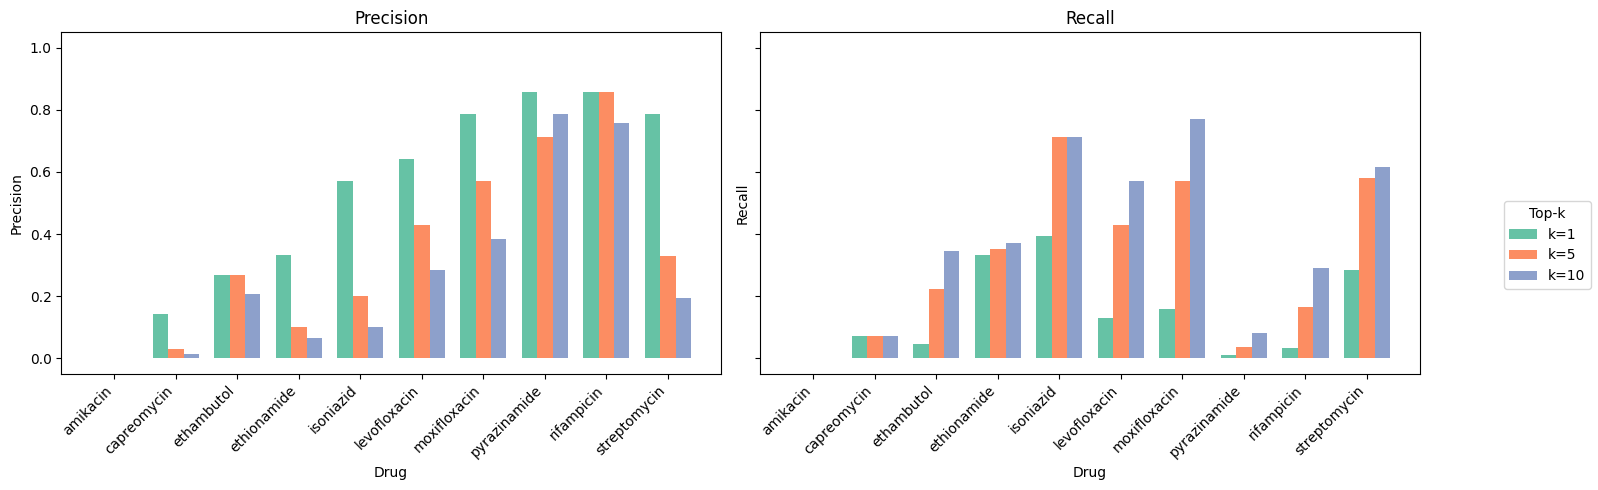

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
import numpy as np

# df = pd.read_csv("data/latest/results/interpretability/combined/combined_precision_recall_all_models.csv")

# ── drug-level aggregation (mean of genes) ────────────────────
agg = (df.groupby(["drug", "k_req"], as_index=False)
         .agg({"precision":"mean", "recall":"mean"}))

drugs   = agg["drug"].unique()
k_vals  = [1, 5, 10]
colours = plt.cm.Set2(range(len(k_vals)))   # distinct colours for k’s
x = np.arange(len(drugs))                   # positions for drugs
bar_width = 0.25                            # width per bar

fig, axes = plt.subplots(1, 2, figsize=(16,5), sharey=True)

metrics = ["precision", "recall"]
for ax, metric in zip(axes, metrics):
    for j, (k, c) in enumerate(zip(k_vals, colours)):
        sub = (agg[agg["k_req"]==k]
                 .set_index("drug")
                 .reindex(drugs))   # align drugs order
        ax.bar(x + j*bar_width, sub[metric], 
               width=bar_width, label=f"k={k}", color=c)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(metric.capitalize())
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(drugs, rotation=45, ha="right")
    ax.set_xlabel("Drug")
    ax.set_ylabel(metric.capitalize())

# ONE legend for all
fig.legend([f"k={k}" for k in k_vals], loc="center right", title="Top-k")
fig.tight_lat(rect=[0,0,0.90,1])  
fig.savefig("data/latest/results/interpretability/combined/precision_recall_grouped_by_drug.png", dpi=300)
plt.show()


In [18]:
import numpy as np
import pandas as pd

IN_CSV  = "data/latest/results/interpretability/combined/combined_precision_recall_all_models_shapall.csv"
OUT_LONG  = "data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_long.csv"
OUT_PIVOT = "data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_pivot.csv"

# ---- choose which "k" to use: "k_req" (recommended) or "k_eff"
K_COL = "k_req"

# How to aggregate across folds at the gene level for a given k.
# - "max" = best fold’s TP per (drug,variant,gene,k) → optimistic discovery summary
# - "mean" = average across folds
AGG_FUN = "max"   # or "mean"

df = pd.read_csv(IN_CSV)

# Basic hygiene
need_cols = {"variant","drug","gene",K_COL,"TP","total_res_pos"}
missing = need_cols.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns in input: {missing}")

# enforce numeric
for c in [K_COL, "TP", "total_res_pos"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) Per (drug, variant, gene, k): aggregate across folds
per_gene_k = (
    df.groupby(["drug","variant","gene", K_COL], as_index=False)
      .agg(TP=("TP", AGG_FUN),
           total_res_pos=("total_res_pos", "max"))  # constant within gene; "max" guards dup rows
)

# 2) Per (drug, variant, k): sum over genes (handles multi-gene drugs)
per_drug_model_k = (
    per_gene_k.groupby(["drug","variant", K_COL], as_index=False)
              .agg(TP=("TP","sum"),
                   total_res_pos=("total_res_pos","sum"))
)

# 3) % discovered
per_drug_model_k["pct_discovered"] = np.where(
    per_drug_model_k["total_res_pos"] > 0,
    100.0 * per_drug_model_k["TP"] / per_drug_model_k["total_res_pos"],
    0.0
)

# 4) Save LONG table (drug, variant, k, TP, total_res_pos, %)
long_out = (per_drug_model_k
            .rename(columns={K_COL: "k"})
            .sort_values(["drug","variant","k"])
           )
long_out["pct_discovered"] = long_out["pct_discovered"].round(1)
long_out.to_csv(OUT_LONG, index=False)

# 5) Also save a wide PIVOT with MultiIndex columns (variant, k)
pivot = long_out.pivot_table(
    index="drug",
    columns=["variant","k"],
    values="pct_discovered",
    aggfunc="first"  # already unique
).sort_index().sort_index(axis=1)
pivot.to_csv(OUT_PIVOT)

print("Saved:")
print("  • LONG :", OUT_LONG)
print("  • PIVOT:", OUT_PIVOT)
print("\nPreview (LONG):")
print(long_out.head(12))
print("\nPreview (PIVOT) — columns are (variant, k):")
print(pivot.iloc[:5, :10])  # first 5 drugs × first 10 columns


Saved:
  • LONG : data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_long.csv
  • PIVOT: data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_pivot.csv

Preview (LONG):
        drug      variant   k  TP  total_res_pos  pct_discovered
0   amikacin          cnn   1   0              0             0.0
1   amikacin          cnn   5   0              0             0.0
2   amikacin          cnn  10   0              0             0.0
3   amikacin      full320   1   0              0             0.0
4   amikacin      full320   5   0              0             0.0
5   amikacin      full320  10   0              0             0.0
6   amikacin        pca10   1   0              0             0.0
7   amikacin        pca10   5   0              0             0.0
8   amikacin        pca10  10   0              0             0.0
9   amikacin  transformer   1   0              0             0.0
10  amikacin  transformer   5   0              0             0.0
11  amika

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load table
df = pd.read_csv("data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_long.csv")

# Step 1. Find best k globally
k_summary = df.groupby("k")["pct_discovered"].mean().reset_index()
best_k = k_summary.sort_values("pct_discovered", ascending=False).iloc[0]["k"]
print("Best k overall:", best_k)
print(k_summary)

# Step 2. Best model at best k
bestk_df = df[df["k"] == best_k]
model_summary = bestk_df.groupby("variant")["pct_discovered"].mean().sort_values(ascending=False)
print("\nBest models at k =", best_k)
print(model_summary)



Best k overall: 10.0
    k  pct_discovered
0   1       11.682090
1   5       30.028358
2  10       39.180597

Best models at k = 10.0
variant
cnn            54.570000
logreg         44.611111
ridge          40.811111
pca10          39.410000
lasso          36.466667
transformer    35.090000
full320        23.740000
Name: pct_discovered, dtype: float64


In [20]:
# Step 4. Best model per drug at best k
# Get best model(s) per drug at best k, including ties
best_per_drug = bestk_df.groupby("drug").apply(
    lambda g: g[g["pct_discovered"] == g["pct_discovered"].max()]
).reset_index(drop=True)

print(best_per_drug[["drug", "variant", "pct_discovered"]])


            drug      variant  pct_discovered
0       amikacin          cnn             0.0
1       amikacin      full320             0.0
2       amikacin        pca10             0.0
3       amikacin  transformer             0.0
4    capreomycin          cnn            50.0
5     ethambutol          cnn           100.0
6     ethambutol        lasso           100.0
7     ethambutol       logreg           100.0
8    ethionamide          cnn            30.0
9      isoniazid       logreg           100.0
10     isoniazid        ridge           100.0
11  levofloxacin          cnn            80.0
12  levofloxacin  transformer            80.0
13  moxifloxacin          cnn           100.0
14  pyrazinamide          cnn            10.5
15    rifampicin          cnn            38.5
16  streptomycin          cnn            70.0


/tmp/ipykernel_3188638/1412625604.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_per_drug = bestk_df.groupby("drug").apply(


In [21]:
drug_wins = best_per_drug["variant"].value_counts()
print(drug_wins)


variant
cnn            9
transformer    2
logreg         2
full320        1
pca10          1
lasso          1
ridge          1
Name: count, dtype: int64


In [ ]:
comp_pivot["better"] = (comp_pivot["pca10"] > comp_pivot["full320"]).map({True:"PCA10", False:"Full320"})
print(comp_pivot[["pca10","full320","better"]])
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=bestk_df, x="drug", y="pct_discovered", hue="variant",
            order=comp_pivot.index, hue_order=model_summary.index)  # order by global ranking
plt.xticks(rotation=45, ha="right")
plt.ylabel("% TP discovered at k=10")
plt.title("Drug-level performance distribution across models (k=10)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_lat()
plt.show()

# Step 3. PCA10 vs Full320 comparison per drug
comp = bestk_df[bestk_df["variant"].isin(["pca10", "full320"])]
comp_pivot = comp.pivot(index="drug", columns="variant", values="pct_discovered")

# Plot
comp_pivot.plot(kind="bar", figsize=(10,6))
plt.ylabel("Mean % TP discovered")
plt.title(f"Causal Variant Discovery at k={best_k}: PCA10 vs Full320")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_lat()
plt.show()

In [25]:
import pandas as pd

# Load data
df = pd.read_csv("data/latest/results/interpretability/combined/tp_pct_per_drug_model_allk_long.csv")

# Step 1. Best k globally
k_summary = df.groupby("k")["pct_discovered"].mean().reset_index()
best_k = k_summary.sort_values("pct_discovered", ascending=False).iloc[0]["k"]
print("Best k overall:", best_k)

# Step 2. Filter to best k
bestk_df = df[df["k"] == best_k]

# Step 3. Rank models per drug (higher pct_discovered = better)
def rank_models(g):
    g = g.copy()
    g["rank"] = g["pct_discovered"].rank(method="min", ascending=False).astype(int)
    best_val = g["pct_discovered"].max()
    seqmean_val = g[g["variant"] == "seqmean"]["pct_discovered"].max() if "seqmean" in g["variant"].values else None
    g["best_diff_vs_seqmean"] = (best_val - seqmean_val) if seqmean_val is not None else None
    return g

ranked = bestk_df.groupby("drug").apply(rank_models).reset_index(drop=True)

# Step 4. Extract summary tables
best_per_drug = ranked[ranked["rank"] == 1]   # all best models (ties included)
second_per_drug = ranked[ranked["rank"] == 2] # all second-place models

# === Outputs ===
print("\nBest models per drug (with ties):")
print(best_per_drug[["drug","variant","pct_discovered","best_diff_vs_seqmean"]])

print("\nSecond-place models per drug:")
print(second_per_drug[["drug","variant","pct_discovered"]])

# How many wins each model got (ties count too)
print("\nModel win counts (including ties):")
print(best_per_drug["variant"].value_counts())


Best k overall: 10.0

Best models per drug (with ties):
            drug      variant  pct_discovered best_diff_vs_seqmean
0       amikacin          cnn             0.0                 None
1       amikacin      full320             0.0                 None
2       amikacin        pca10             0.0                 None
3       amikacin  transformer             0.0                 None
4    capreomycin          cnn            50.0                 None
11    ethambutol          cnn           100.0                 None
13    ethambutol        lasso           100.0                 None
14    ethambutol       logreg           100.0                 None
18   ethionamide          cnn            30.0                 None
28     isoniazid       logreg           100.0                 None
30     isoniazid        ridge           100.0                 None
32  levofloxacin          cnn            80.0                 None
38  levofloxacin  transformer            80.0                 None
39  mo

/tmp/ipykernel_3188638/3694287999.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ranked = bestk_df.groupby("drug").apply(rank_models).reset_index(drop=True)


/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


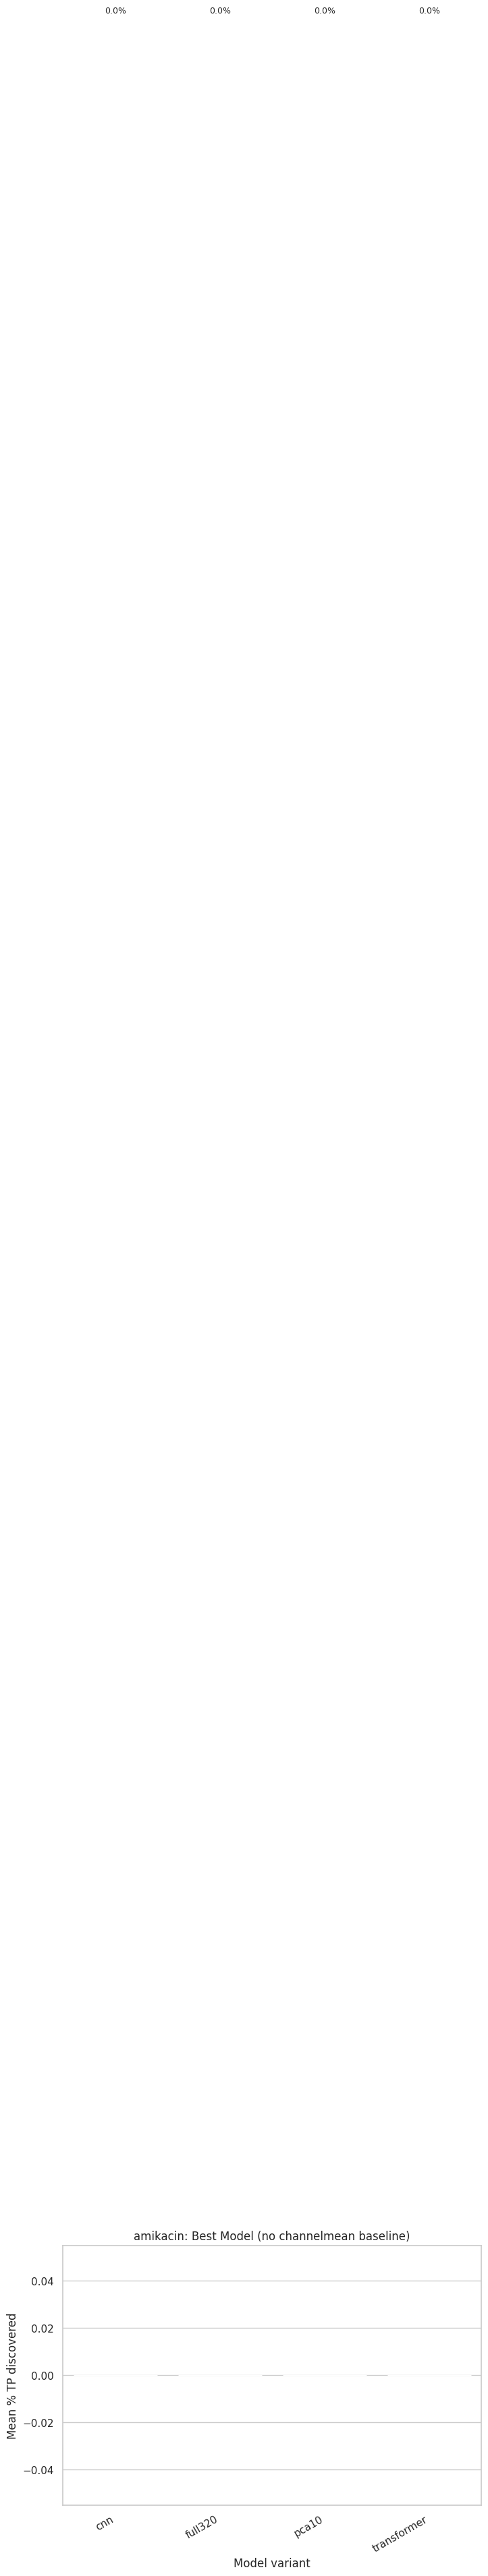

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)


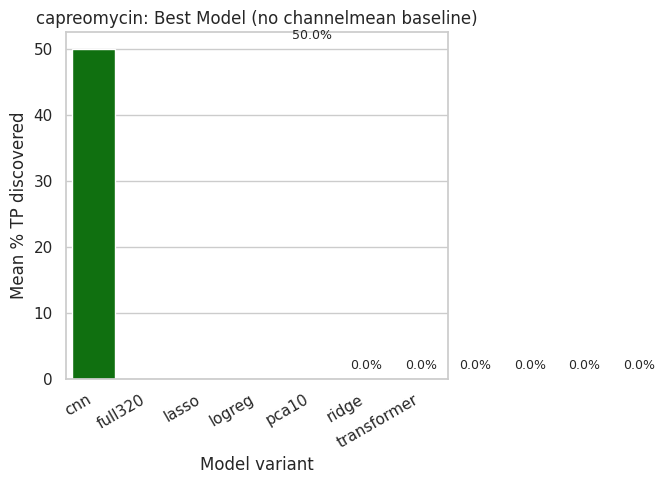

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


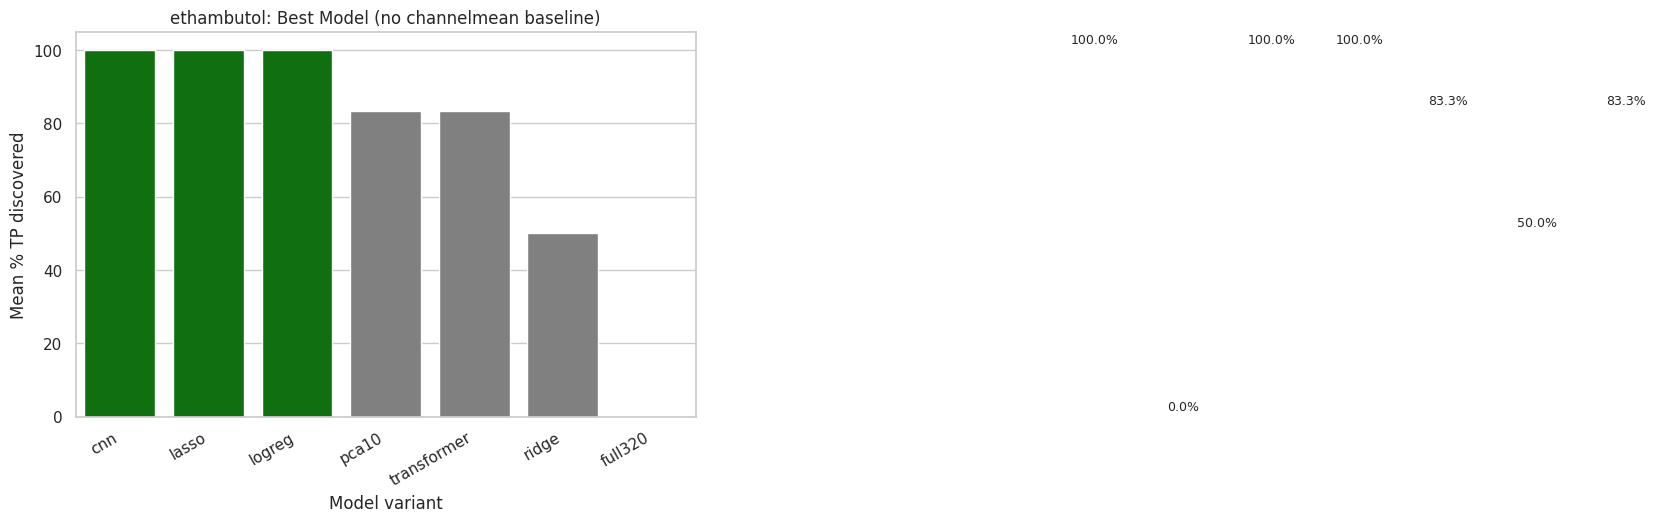

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


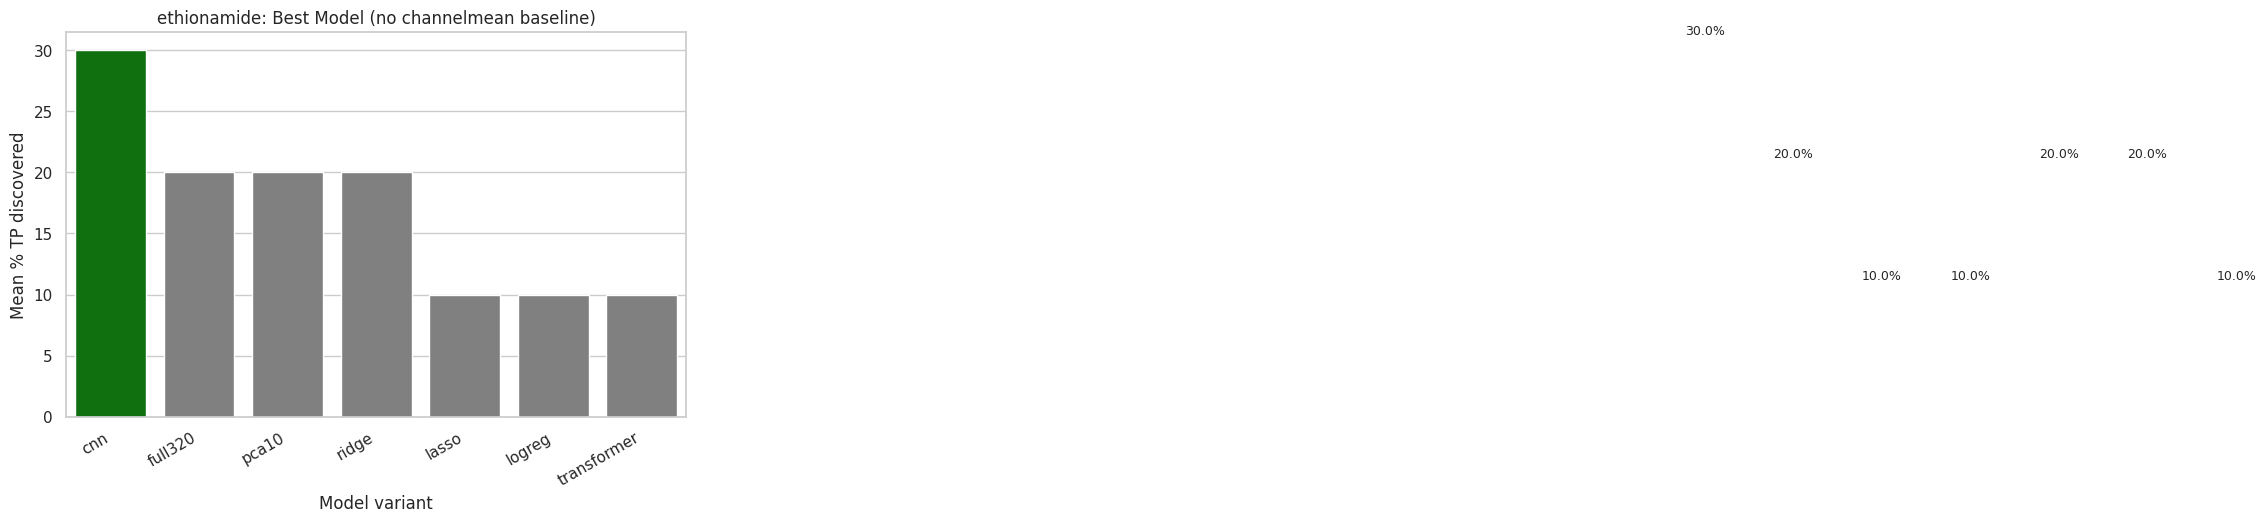

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


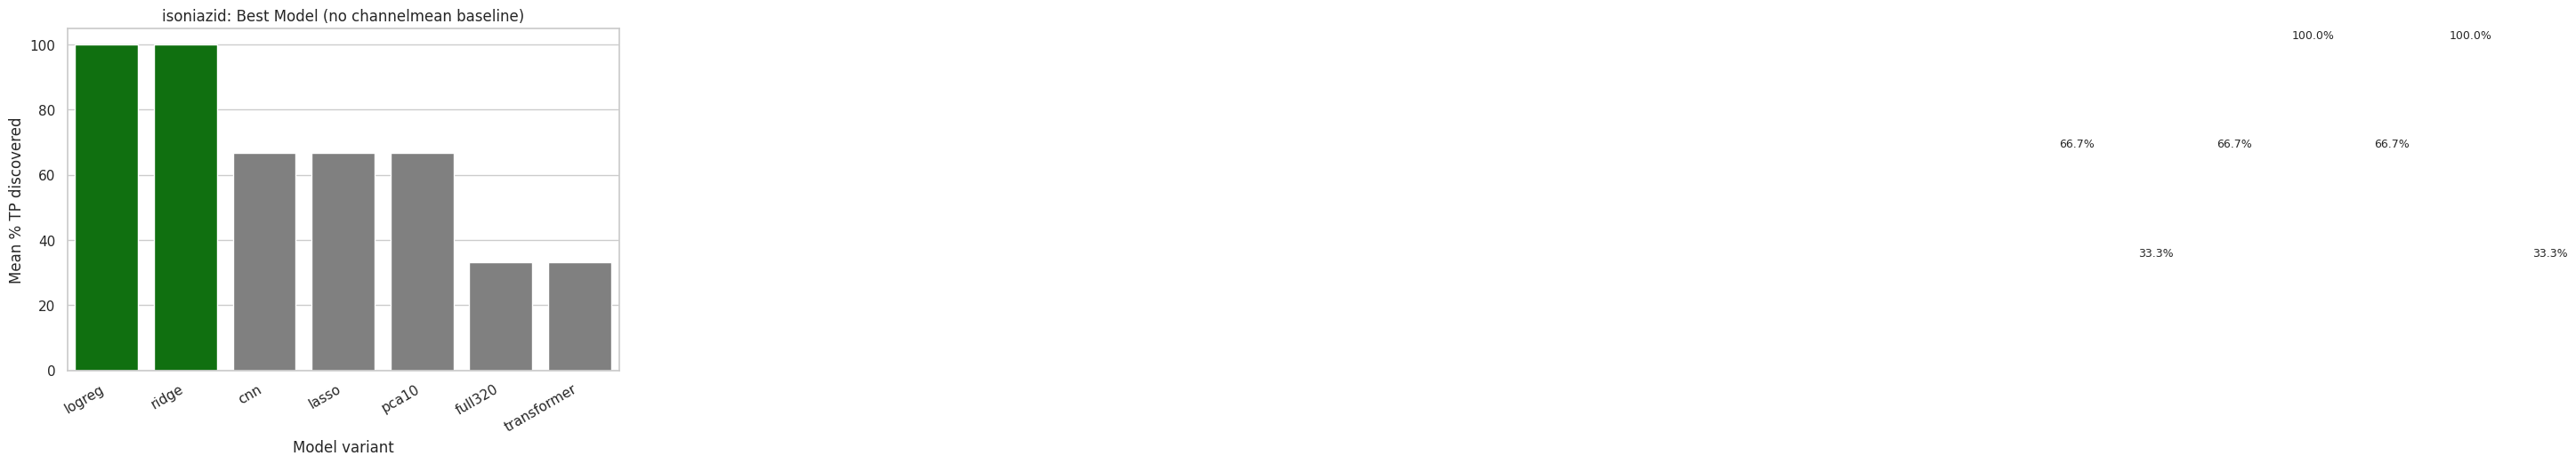

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


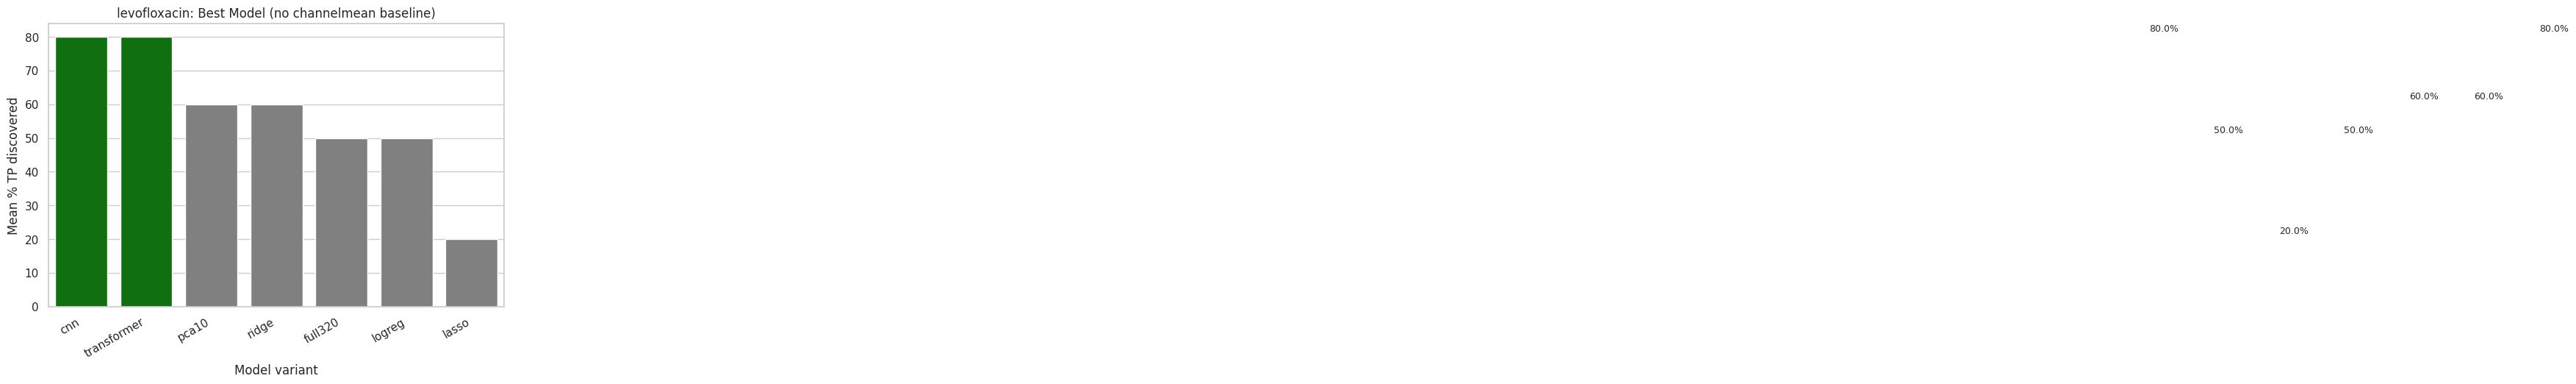

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


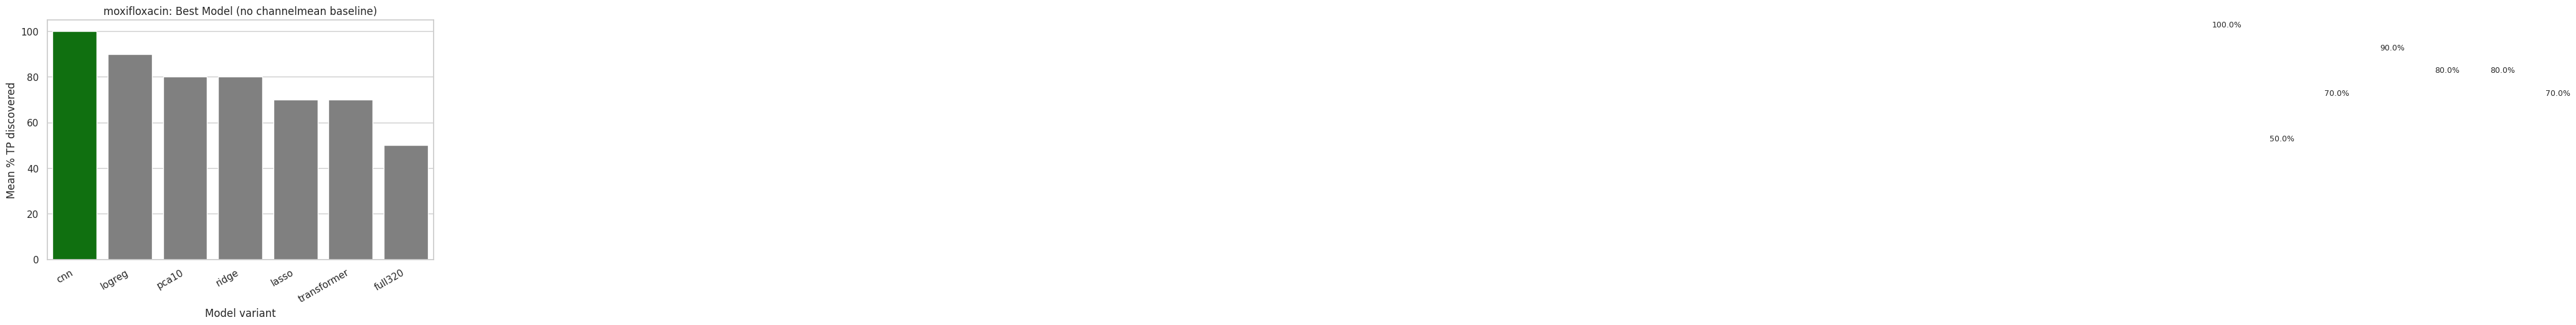

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


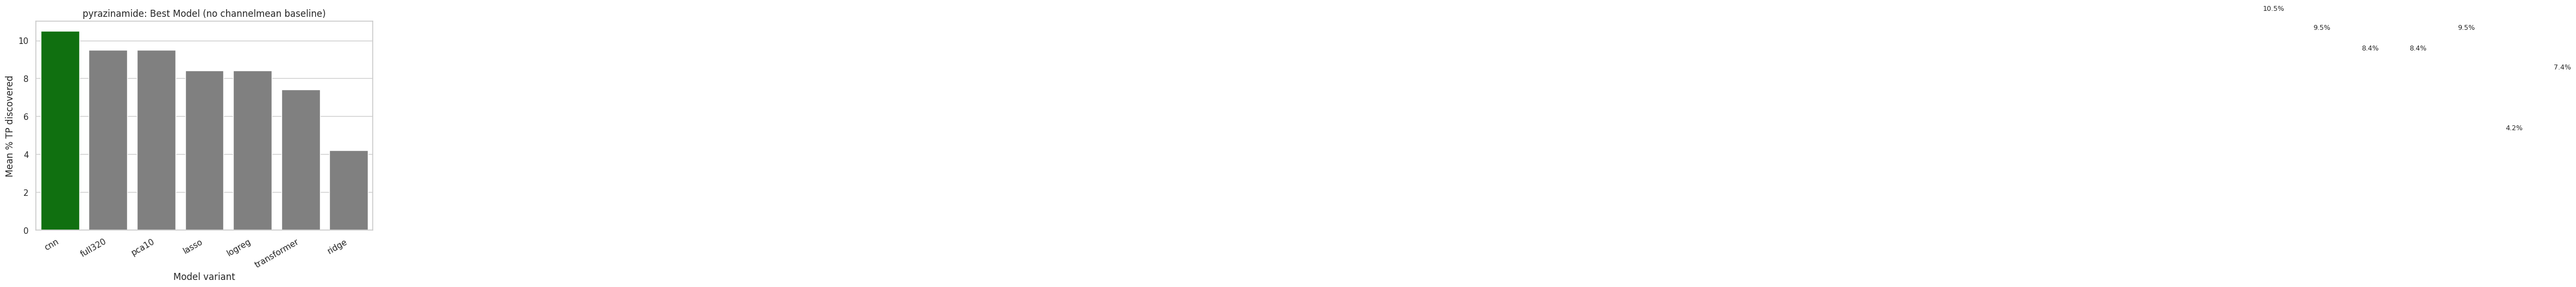

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


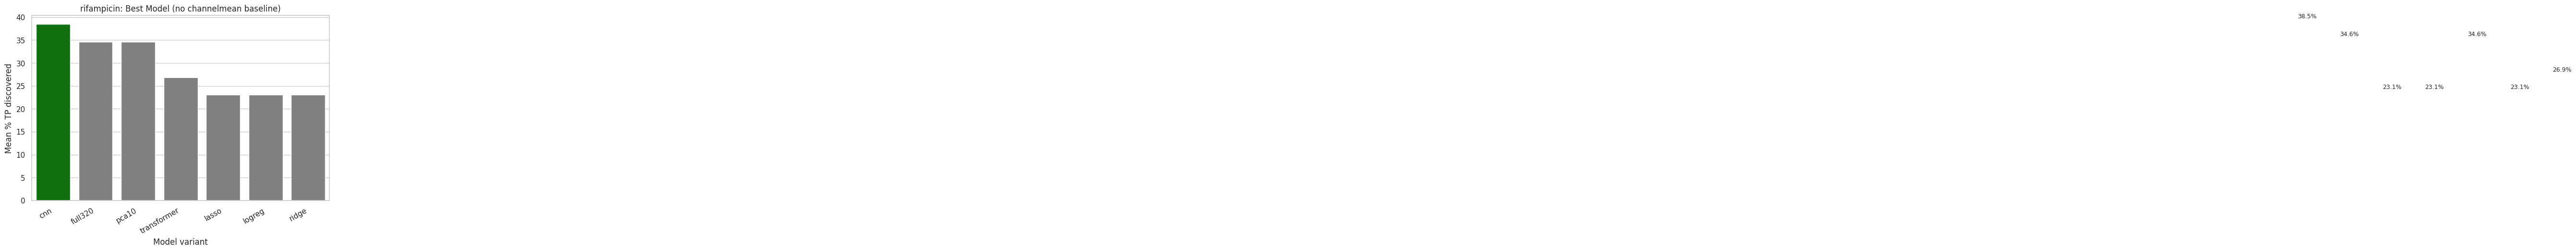

/tmp/ipykernel_3188638/3850055435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
/tmp/ipykernel_3188638/3850055435.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


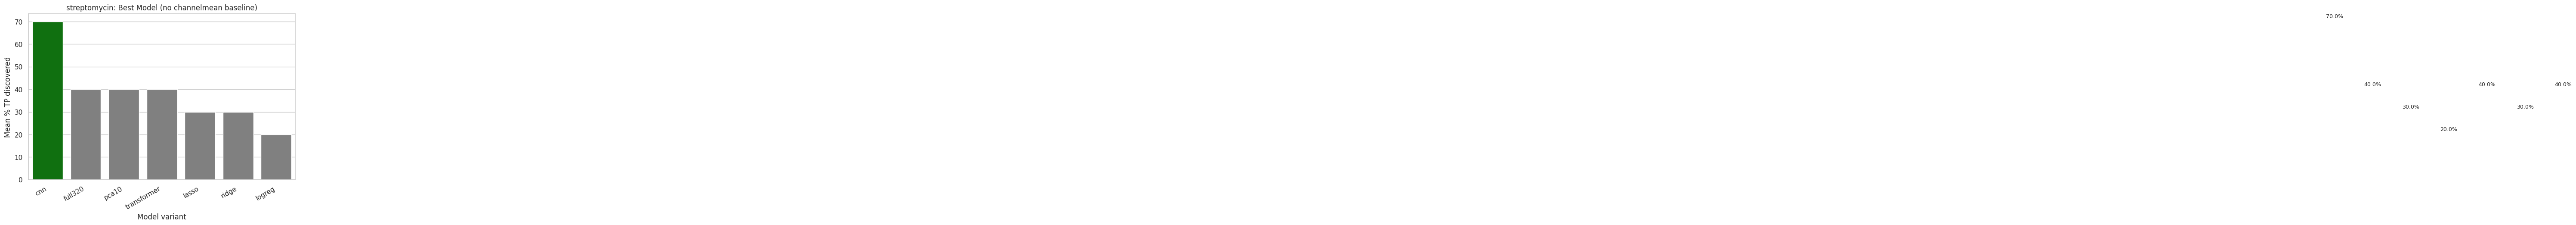

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure seaborn style is nice
sns.set(style="whitegrid")

# Iterate over drugs
for drug, g in ranked.groupby("drug"):
    plt.figure(figsize=(8,5))
    
    # Sort by score
    g_sorted = g.sort_values("pct_discovered", ascending=False)
    
    # Colors: channelmean = red, best = green, others = gray
    colors = []
    best_val = g_sorted["pct_discovered"].max()
    best_variants = g_sorted[g_sorted["pct_discovered"] == best_val]["variant"].tolist()
    for v in g_sorted["variant"]:
        if v == "channelmean":
            colors.append("red")
        elif v in best_variants:
            colors.append("green")
        else:
            colors.append("gray")
    
    # Barplot
    ax = sns.barplot(x="variant", y="pct_discovered", data=g_sorted, palette=colors)
    
    # Annotate bars
    for i, row in g_sorted.iterrows():
        ax.text(i, row["pct_discovered"]+1, f"{row['pct_discovered']:.1f}%", 
                ha="center", va="bottom", fontsize=9)
    
    # Annotate improvement
    base_val = g_sorted[g_sorted["variant"]=="channelmean"]["pct_discovered"].max()
    if pd.notnull(base_val):
        diff = best_val - base_val
        plt.title(f"{drug}: Best vs Channelmean (+{diff:.1f}%)")
    else:
        plt.title(f"{drug}: Best Model (no channelmean baseline)")
    
    plt.ylabel("Mean % TP discovered")
    plt.xlabel("Model variant")
    plt.xticks(rotation=30, ha="right")
    plt.tight_lat()
    plt.show()


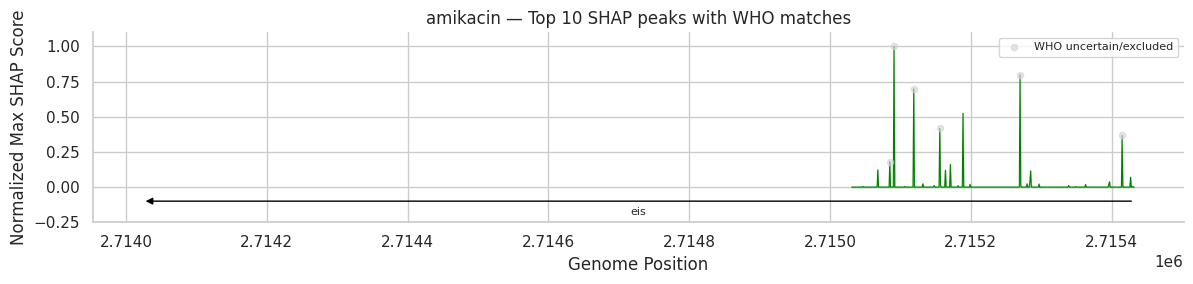

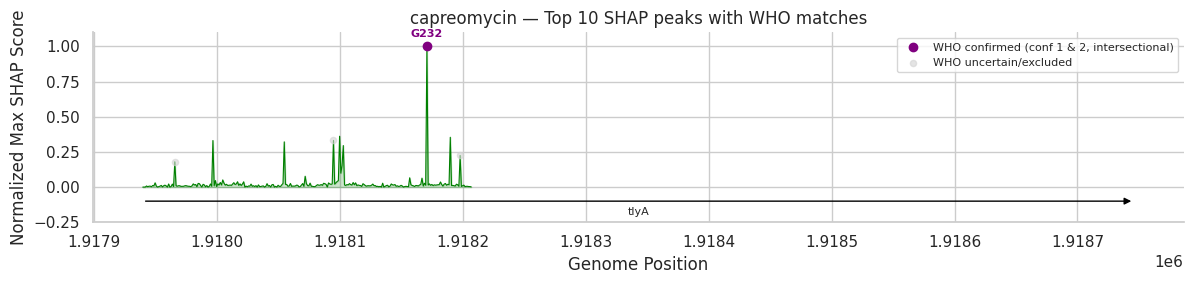

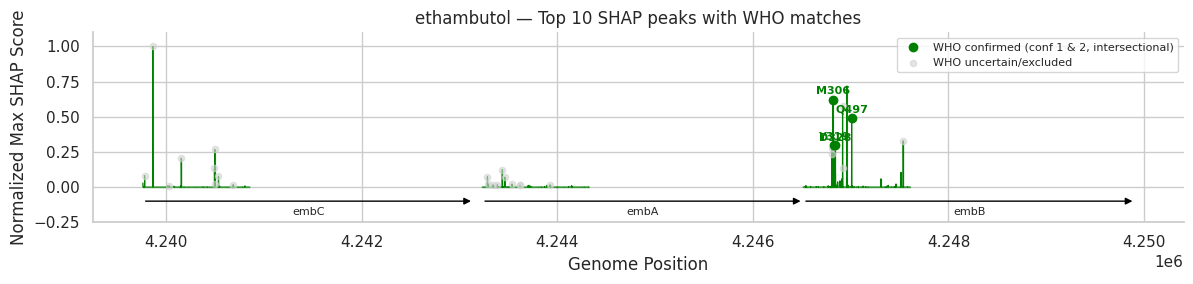

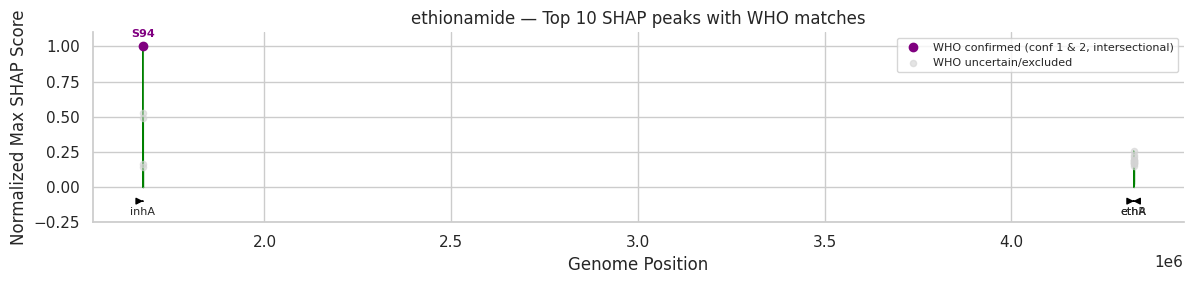

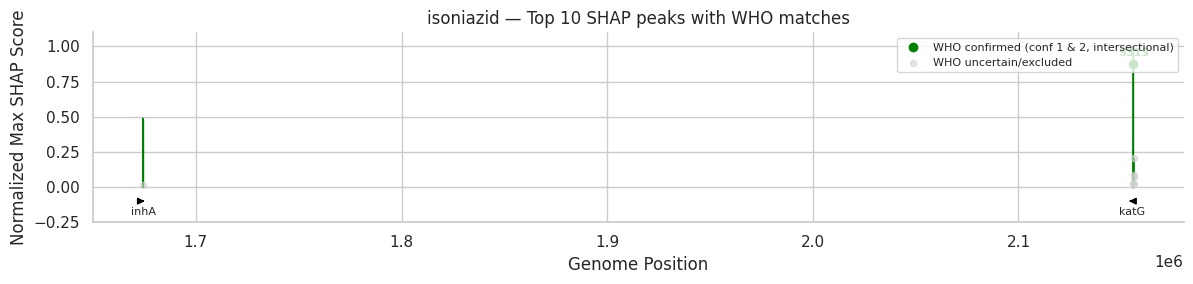

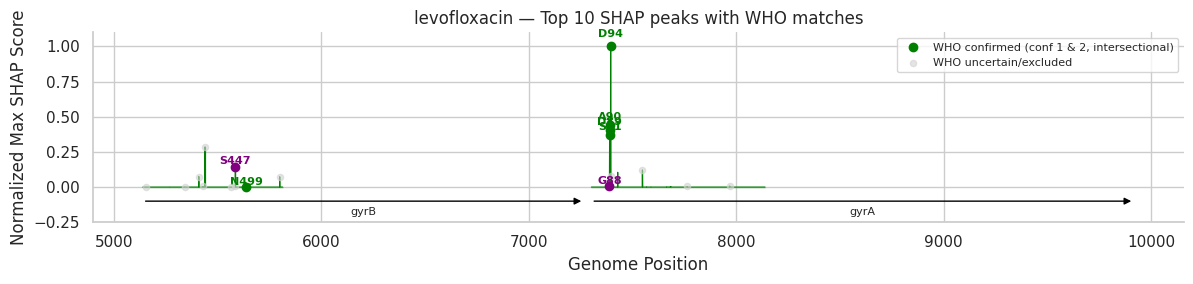

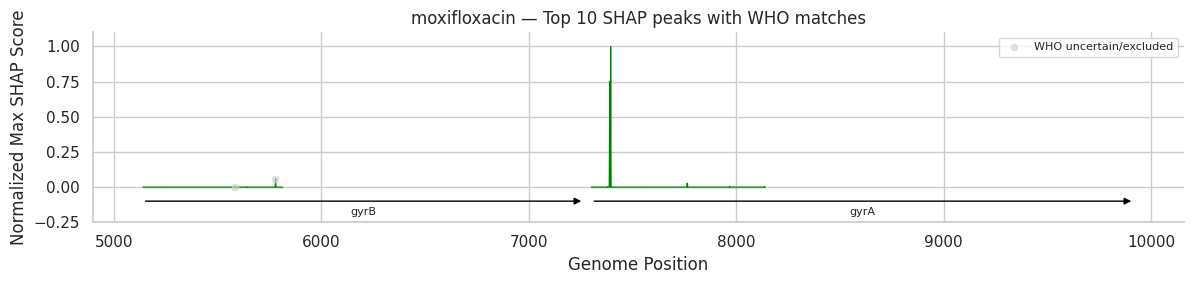

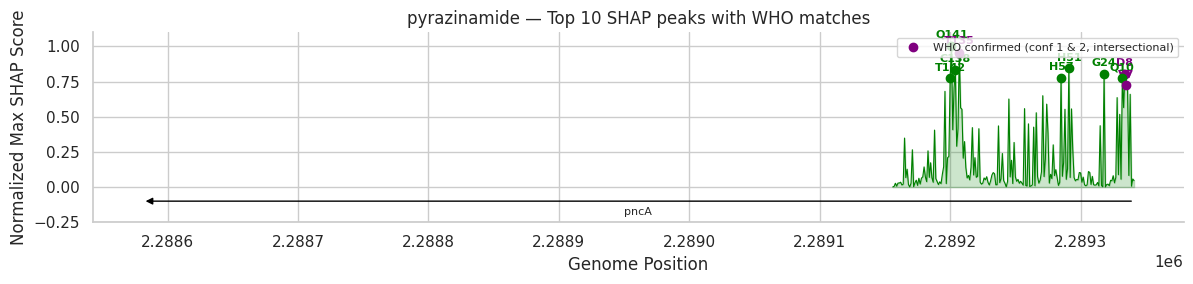

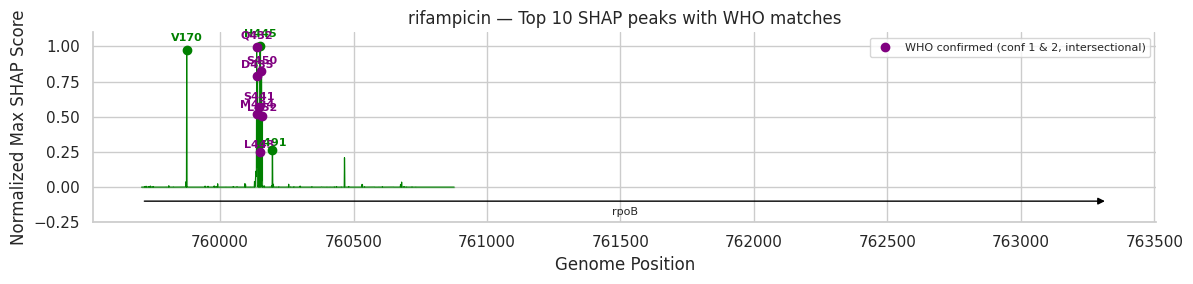

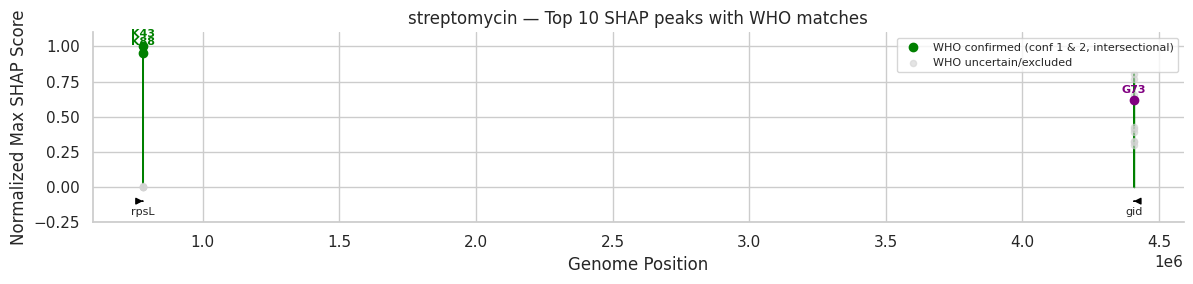

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import glob, os

# === Parameters ===
shap_dir = "data/latest/results/interpretability/cnn/pr_tables/"
who_df   = pd.read_csv("data/filtered_variants_output.csv")

gene_coord_map = {
    "tlyA": [1917940, 1918746, "pos"],
    "ethA": [4325904, 4327473, "neg"],
    "ethR": [4327549, 4328299, "pos"],
    "katG": [2153789, 2156211, "neg"],
    "eis": [2714024, 2715432, "neg"],
    "pncA": [2288581, 2289341, "neg"],
    "gid": [4407428, 4408302, "neg"],
    "rpsL": [781460, 782034, "pos"],
    "inhA": [1674202, 1675111, "pos"],
    "rpoB": [759706, 763325, "pos"],
    "gyrB": [5140, 7267, "pos"],
    "gyrA": [7302, 9918, "pos"],
    "embC": [4239763, 4243147, "pos"],
    "embA": [4243233, 4246517, "pos"],
    "embB": [4246514, 4249910, "pos"]
}

ALLOWED_CONF = ['1) Assoc w R', '2) Assoc w R - Interim']
top_n = 10  # top N SHAP peaks to annotate

def variant_color(conf):
    return "green" if conf.startswith("1)") else "purple"

# === Get all SHAP files ===
shap_files = glob.glob(os.path.join(shap_dir, "*_ranked_SHAP.csv"))
drug_names = sorted(set([os.path.basename(f).split("_")[0] for f in shap_files]))

for drug in drug_names:
    drug_files = [f for f in shap_files if os.path.basename(f).startswith(drug)]
    
    # Find max SHAP value across all genes for this drug
    max_val = 0
    for shap_file in drug_files:
        shap_df = pd.read_csv(shap_file)
        max_val = max(max_val, shap_df["MaxAbsSHAP"].max())
    
    fig, ax = plt.subplots(figsize=(12, 3))
    
    for shap_file in drug_files:
        fname = os.path.basename(shap_file)
        _, gene, _ = fname.split("_", 2)
        if gene not in gene_coord_map:
            continue
        
        start, end, strand = gene_coord_map[gene]
        shap_df = pd.read_csv(shap_file).sort_values("Residue_Position")
        
        # Normalize
        shap_df["Norm_SHAP"] = shap_df["MaxAbsSHAP"] / max_val
        
        # Map residue positions to genome coordinates
        shap_df["Genome_Pos"] = start + shap_df["Residue_Position"] if strand == "pos" \
                                else end - shap_df["Residue_Position"]
        
        # Plot SHAP curve in green
        ax.plot(shap_df["Genome_Pos"], shap_df["Norm_SHAP"], color="green", lw=0.8)
        ax.fill_between(shap_df["Genome_Pos"], 0, shap_df["Norm_SHAP"], color="green", alpha=0.2)
        
        # Gene arrow
        arrow_start = (start, -0.1)
        arrow_end   = (end, -0.1)
        arrow = patches.FancyArrowPatch(
            arrow_start if strand == "pos" else arrow_end,
            arrow_end if strand == "pos" else arrow_start,
            arrowstyle='-|>', mutation_scale=10, color="black", lw=1
        )
        ax.add_patch(arrow)
        ax.text((start + end) / 2, -0.18, gene, ha="center", va="center", fontsize=8)
        
        # WHO variants for this gene & drug
        gene_who = who_df[(who_df["drug"].str.lower() == drug.lower()) &
                          (who_df["gene"] == gene)]
        
        bona_fide = gene_who[
            gene_who["confidence"].isin(ALLOWED_CONF) &
            (gene_who["intersectional"] == True)
        ]
        excluded = gene_who.drop(bona_fide.index)
        
        # Top N peaks for this gene
        top_peaks = shap_df.nlargest(top_n, "MaxAbsSHAP")
        
        for _, peak in top_peaks.iterrows():
            peak_pos_0idx = int(peak["Residue_Position"])
            peak_pos_1idx = peak_pos_0idx + 1
            peak_val = peak["Norm_SHAP"]
            
            # Check matches
            match_bona = bona_fide[bona_fide["aa_pos"] == peak_pos_1idx]
            match_excl = excluded[excluded["aa_pos"] == peak_pos_1idx]
            
            if not match_bona.empty:
                mut_label = match_bona.iloc[0]["aa_ref"] + str(peak_pos_1idx)
                col = variant_color(match_bona.iloc[0]["confidence"])
                ax.scatter(peak["Genome_Pos"], peak_val, color=col, zorder=5, label="bona_fide")
                ax.text(peak["Genome_Pos"], peak_val * 1.05, mut_label,
                        ha="center", va="bottom", fontsize=8, fontweight="bold", color=col)
            
            elif not match_excl.empty:
                ax.scatter(peak["Genome_Pos"], peak_val, color="lightgray", s=20, zorder=3, alpha=0.6, label="uncertain")
    
    # Format
    ax.set_ylabel("Normalized Max SHAP Score")
    ax.set_xlabel("Genome Position")
    ax.set_ylim(-0.25, 1.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.title(f"{drug} — Top {top_n} SHAP peaks with WHO matches")
    
    # Legend (deduplicated handles)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend_labels = {
        "bona_fide": "WHO confirmed (conf 1 & 2, intersectional)",
        "uncertain": "WHO uncertain/excluded"
    }
    ax.legend([by_label[k] for k in legend_labels if k in by_label],
              [legend_labels[k] for k in legend_labels if k in by_label],
              loc="upper right", fontsize=8)
    
    plt.tight_lat()
    plt.savefig(f"data/latest/results/interpretability/combined/{drug}_topmatchgenometrack.png", dpi=300)
    plt.show()


## tables

In [ ]:
from tqdm import tqdm
import pandas as pd

def build_train_test_split(drug, test_size=0.2, seed=42):
    if drug in single_drugs:
        gene = single_drugs[drug][0]
        paths = [f"data/latest/sequence_data_csv/{gene}_{drug.upper()}_combined_sequence_data.csv"]
    else:
        genes = multi_drugs[drug]
        paths = [f"data/latest/sequence_data_csv/{g}_{drug.upper()}_combined_sequence_data.csv"
                 for g in genes]

    dfs = []
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Expected file not found: {p}")
        dfs.append(pd.read_csv(p, usecols=["Filename", "Phenotype"]))

    ph = pd.concat(dfs, ignore_index=True)
    ph["drug"] = drug
    ph["label"] = (ph["Phenotype"] == "R").astype(int)

    train_df, test_df = train_test_split(
        ph, test_size=test_size, random_state=seed, stratify=ph["label"]
    )
    return train_df, test_df


def make_summary_table(df, drugs):
    rows = []
    for drug in drugs:
        subset = df[df["drug"] == drug]
        resistant = (subset["label"] == 1).sum()
        susceptible = (subset["label"] == 0).sum()
        total = resistant + susceptible
        prop = resistant / total if total > 0 else 0
        rows.append({
            "Drug": drug.capitalize(),
            "Resistant (n)": resistant,
            "Susceptible (n)": susceptible,
            "Total (n)": total,
            "Resistant proportion": round(prop, 3)
        })
    table = pd.DataFrame(rows)
    table.loc["Total isolates"] = [
        "Total isolates",
        table["Resistant (n)"].sum(),
        table["Susceptible (n)"].sum(),
        table["Total (n)"].sum(),
        "-"
    ]
    return table


# ---- Run for all drugs ----
drug_list = [
    "isoniazid","rifampicin","ethambutol","pyrazinamide","streptomycin",
    "amikacin","capreomycin","moxifloxacin","levofloxacin","ethionamide"
]

train_all, test_all = [], []
for d in tqdm(drug_list):
    train_df, test_df = build_train_test_split(d)
    train_all.append(train_df)
    test_all.append(test_df)

# Merge all drugs
train_all_df = pd.concat(train_all, ignore_index=True)
test_all_df  = pd.concat(test_all, ignore_index=True)

# Build summary tables
train_table = make_summary_table(train_all_df, drug_list)
test_table  = make_summary_table(test_all_df, drug_list)


In [ ]:
train_table

In [ ]:
test_table

In [ ]:
import pandas as pd

# Load WHO catalog variants
df = pd.read_csv("data/filtered_variants_output.csv")

# Filter missense + intersectional
df = df[(df["effect"] == "missense_variant") & (df["intersectional"] == True)]
# Deduplicate by drug + variant
df = df.drop_duplicates(subset=["drug", "variant"])


# Normalize confidence labels
conf_map = {
    "1) Assoc w R": "Assoc w R",
    "2) Assoc w R - Interim": "Assoc w R",
    "3) Uncertain significance": "Uncertain",
    "5) Not assoc w R": "Not assoc w R",
    "4) Not assoc w R - Interim": "Not assoc w R"
}


df["conf_group"] = df["confidence"].map(conf_map)
# Deduplicate at residue level (drug + gene + aa_pos)
df = df.drop_duplicates(subset=["drug","gene","aa_pos","conf_group"])


# Count per drug x confidence
summary = (
    df.groupby(["drug", "conf_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Add total column
summary["Total"] = summary.drop(columns=["drug"]).sum(axis=1)

summary


In [ ]:
df.columns

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- Mapping ---
single_drugs = {
    "rifampicin" : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"]
}

multi_drugs = {
    "streptomycin": ["rpsL", "gid"],
    "isoniazid"   : ["katG", "inhA"],
    "ethionamide" : ["ethA", "ethR","inhA"],
    "ethambutol"  : ["embC","embA","embB"],
    "moxifloxacin": ["gyrA", "gyrB"],
    "levofloxacin": ["gyrA", "gyrB"]
}


# --- Train/Test Split ---
def build_train_test_split(drug, test_size=0.2, seed=42):
    if drug in single_drugs:
        genes = single_drugs[drug]
    else:
        genes = multi_drugs[drug]

    paths = [
        f"data/latest/sequence_data_csv/{g}_{drug.upper()}_combined_sequence_data.csv"
        for g in genes
    ]

    dfs = []
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Expected file not found: {p}")
        dfs.append(pd.read_csv(p, usecols=["Filename", "Phenotype"]))

    # Concatenate and deduplicate so each isolate is counted once per drug
    ph = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=["Filename", "Phenotype"])

    ph["drug"] = drug
    ph["label"] = (ph["Phenotype"] == "R").astype(int)

    train_df, test_df = train_test_split(
        ph, test_size=test_size, random_state=seed, stratify=ph["label"]
    )
    return train_df, test_df


# --- Summary Table ---
def make_summary_table(df, drugs):
    rows = []
    for drug in drugs:
        subset = df[df["drug"] == drug]
        resistant = (subset["label"] == 1).sum()
        susceptible = (subset["label"] == 0).sum()
        total = resistant + susceptible
        prop = resistant / total if total > 0 else 0
        rows.append({
            "Drug": drug.capitalize(),
            "Resistant (n)": resistant,
            "Susceptible (n)": susceptible,
            "Total (n)": total,
            "Resistant proportion": round(prop, 3)
        })
    table = pd.DataFrame(rows)

    return table


# --- Driver ---
drug_list = [
    "isoniazid","rifampicin","ethambutol","pyrazinamide","streptomycin",
    "amikacin","capreomycin","moxifloxacin","levofloxacin","ethionamide"
]

train_all, test_all = [], []
for d in tqdm(drug_list):
    train_df, test_df = build_train_test_split(d)
    train_all.append(train_df)
    test_all.append(test_df)

# Merge all drugs
train_all_df = pd.concat(train_all, ignore_index=True)
test_all_df  = pd.concat(test_all, ignore_index=True)

# Build summary tables
train_table = make_summary_table(train_all_df, drug_list)
test_table  = make_summary_table(test_all_df, drug_list)

print("\n=== Training set summary ===")
print(train_table)

print("\n=== Test set summary ===")
print(test_table)



=== Training set summary ===
           Drug  Resistant (n)  Susceptible (n)  Total (n)  \
0     Isoniazid           4660             9288      13948   
1    Rifampicin           3895            10170      14065   
2    Ethambutol           2356             9732      12088   
3  Pyrazinamide           1705             8618      10323   
4  Streptomycin           1933             4212       6145   
5      Amikacin            566             2398       2964   
6   Capreomycin            540             2543       3083   
7  Moxifloxacin            310             1984       2294   
8  Levofloxacin             61              154        215   
9   Ethionamide            552             1170       1722   

   Resistant proportion  
0                 0.334  
1                 0.277  
2                 0.195  
3                 0.165  
4                 0.315  
5                 0.191  
6                 0.175  
7                 0.135  
8                 0.284  
9                 0.321  



In [ ]:
train_table